# Group 2

# MECE

| Name                          | Task                                                                 | Sub-task                                         | Comments       |
|-------------------------------|----------------------------------------------------------------------|--------------------------------------------------|----------------|
| Clifford Addison              | Data Preprocessing                                                  | Scaling and Resizing                             | Done           |
|                               |                                                                     | Image Augmentation                               | Done           |
|                               |                                                                     | Train and test data handled correctly            | Done           |
|                               |                                                                     | Gaussian Blur, Histogram Equalization and Intensity thresholds | Done |
| Shahnaz Palakunnil Moosa      | Use pretrained VGG model for transfer learning with custom top layers | Model Trained                                    | Done           |
|                               |                                                                     | Training Time=4.25 hours                                   | Done           |
|                               |                                                                     | AUC =0.9841 and Confusion Matrix Computed Yes               | Done           |
|                               |                                                                     | Overfitting/Underfitting checked and handled Yes     | Done           |
| Mansi Jayeshbhai Sutreja      | Fine-tune the model end-to-end                                      | Model Trained                                    | Done           |
|                               |                                                                     | Training Time?                                   | Done           |
|                               |                                                                     | AUC and Confusion Matrix Computed                | Done           |
|                               |                                                                     | Overfitting/Underfitting checked and handled     | Done           |
| Obianuju Nonyerem Anuma       | Build model using transfer learning with VGG and metadata           | Model Trained                                    | Done           |
|                               |                                                                     | Training Time?                                   | Done           |
|                               |                                                                     | AUC and Confusion Matrix Computed                | Done           |
|                               |                                                                     | Overfitting/Underfitting checked and handled     | Done           |
| Siddhi Pravinbhai Patel       | Fine-tune entire model                                              | Model Trained                                    | Done           |
|                               |                                                                     | Training Time?                                   | Done           |
|                               |                                                                     | AUC and Confusion Matrix Computed                | Done           |
|                               |                                                                     | Overfitting/Underfitting checked and handled     | Done           |
| Kauthara Yakubu               | Use pretrained EfficientNet with selective unfreezing               | Model Trained                                    | Done           |
|                               |                                                                     | Training Time?                                   | Done           |
|                               |                                                                     | AUC and Confusion Matrix Computed                | Done           |
|                               |                                                                     | Overfitting/Underfitting checked and handled     | Done           |
| Utsav Harshadbhai Khamar      | Use pretrained VGG with selective unfreezing                        | Model Trained                                    | Done           |
|                               |                                                                     | Training Time?                                   | Done           |
|                               |                                                                     | AUC and Confusion Matrix Computed                | Done           |
|                               |                                                                     | Overfitting/Underfitting checked and handled     | Done           |
| Saurav Risal                  | Train VGG model without freezing any layers                         | Model Trained                                    | Done           |
|                               |                                                                     | Training Time?                                   | Done           |
|                               |                                                                     | AUC and Confusion Matrix Computed                | Done           |
|                               |                                                                     | Overfitting/Underfitting checked and handled     | Done           |
| Abdullah Ifteqar Mohammed     | Data Centric AI Development (2 Rounds)                              | Interpretability Implemented                     | Major Findings |
|                               |                                                                     | 1st Round of Tuning                              | Issue Fixed    |
|                               |                                                                     | 2nd Round of Tuning                              | Issue Fixed    |

In [ ]:
# Import the necessary Libraries
import pandas as pd
import numpy as np
import json
import os
import random
import shutil
import cv2
import os
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
from PIL import Image
import matplotlib.pyplot as plt

import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")

# Data and Image Preprocessing - Clifford

In [ ]:
# Define photos directory
photos_dir='./Yelp Photos/photos'

In [ ]:
# Load the photos JSON file
photos_df = pd.read_json("./Yelp Photos/photos.json", lines=True)

In [ ]:
# Load the business JSON file
business_df = pd.read_json("./Yelp Photos/yelp_academic_dataset_business.json", lines=True)

In [ ]:
# Check the head of the photos dataframe
photos_df.head()

,photo_id,business_id,caption,label
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food


In [ ]:
# Check the info of the photos dataframe
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


In [ ]:
# Check the labels of the photos
photos_df['label'].unique()

array(['inside', 'outside', 'drink', 'food', 'menu'], dtype=object)

In [ ]:
# Check the head of the business dataframe
business_df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


## Labels Distribution

In [ ]:
# Function for label distribution
def plot_label_distribution(df):
    plt.figure(figsize=(10, 6))
    palette = plt.get_cmap('Set2').colors
    ax = sns.countplot(
        data=df,
        x='label',
        order=df['label'].value_counts().index,
        palette=palette
    )
    plt.title("Image Count per Label")
    plt.xlabel("Label")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)

    # Add count labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 0.3,
            int(height),
            ha="center"
        )

    plt.tight_layout()
    plt.show()

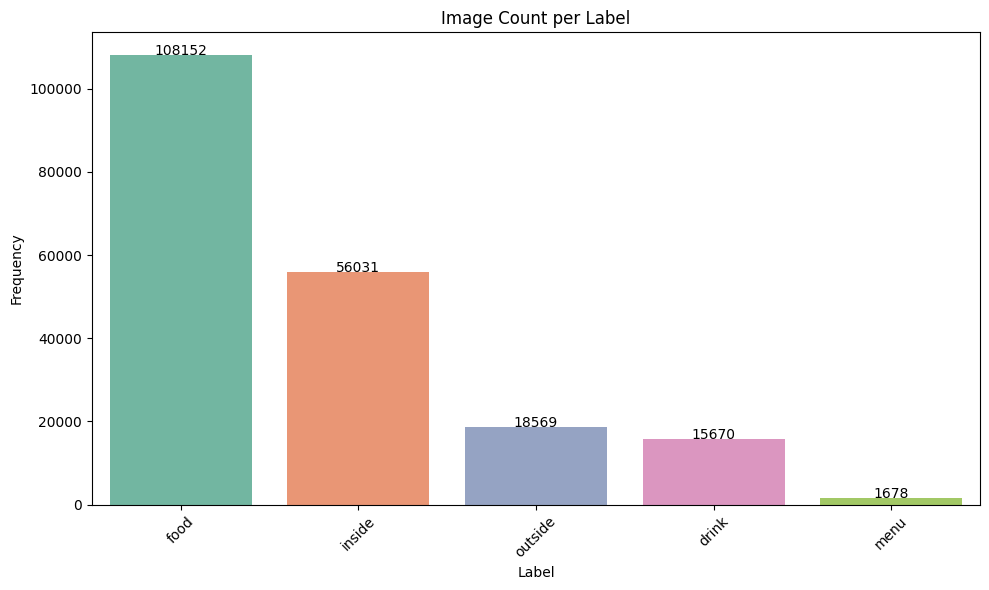

In [ ]:
# Plot the distribution
plot_label_distribution(photos_df)

In [ ]:
# Photo labels count
photos_df.groupby('label')['photo_id'].count()

label
drink       15670
food       108152
inside      56031
menu         1678
outside     18569
Name: photo_id, dtype: int64

## Balance the Dataset by Undersampling

In [ ]:
# Function to balance dataset
def balanced_sample(df, label_col='label'):
    # Find the minimum count across all labels
    min_count = df[label_col].value_counts().min()
    print(f" Sampling {min_count} images per label to ensure class balance.")

    # Perform undersampling for each class
    balanced_df = df.groupby(label_col).apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)

    print(f" Balanced DataFrame created with {len(balanced_df)} rows across {df[label_col].nunique()} classes.")
    return balanced_df

# Usage
photos_df_balanced = balanced_sample(photos_df)

 Sampling 1678 images per label to ensure class balance.
 Balanced DataFrame created with 8390 rows across 5 classes.


In [ ]:
photos_df_balanced.to_csv('balanced_photos_df.csv')

In [ ]:
#  Merge the two dataframes on 'business_id'
df = photos_df_balanced.merge(business_df, on="business_id", how="left")

In [ ]:
df.shape

(8390, 17)

In [ ]:
df.head()

,photo_id,business_id,caption,label,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Chro0cjWAFLtdv-pmGSB6Q,oBNrLz4EDhiscSlbOl8uAw,Bacon Infused Bloody Mary,drink,Ruby Slipper - New Orleans,200 Magazine St,New Orleans,LA,70130,29.951025,-90.067394,4.5,5193,1,"{'NoiseLevel': ''loud'', 'Caters': 'False', 'B...","Restaurants, American (Traditional), American ...","{'Monday': '0:0-0:0', 'Tuesday': '7:30-14:0', ..."
1,BD8F_GP5TiNCiajFVPqZOA,SV04xdj87VOEa4GJ2dZm_g,,drink,You Cha Cafe,1601 N Kings Hwy,Cherry Hill,NJ,08034,39.916220,-75.007034,4.5,44,1,"{'RestaurantsDelivery': 'True', 'WheelchairAcc...","Bubble Tea, Food, Restaurants, Cafes","{'Monday': '0:0-0:0', 'Tuesday': '11:30-18:0',..."
2,Wo16TBTZHfapyV2n_KbCTQ,EM0jUQn-SEnttG8hf-Eq6A,Huckleberry lemon drop at the bar,drink,Bardenay Restaurant & Distillery - Eagle,155 E Riverside St,Eagle,ID,83616,43.686635,-116.352242,4.0,351,1,"{'GoodForKids': 'True', 'BusinessParking': '{'...","Food, Cocktail Bars, Nightlife, Distilleries, ...","{'Monday': '0:0-0:0', 'Tuesday': '11:0-21:0', ..."
3,1gBfJMbZtrgcqqvgDaYWYA,5Z_KrsEQsPE0ibKwhYn3ZQ,,drink,Signature Grill,3800 W Starr Pass Blvd,Tucson,AZ,85745,32.215561,-111.050749,3.5,105,1,"{'RestaurantsGoodForGroups': 'True', 'OutdoorS...","American (New), Restaurants, Southern, Breakfa...","{'Monday': '17:0-22:0', 'Tuesday': '17:0-22:0'..."
4,Qy65xh-hrmPTb2k_-6uZnA,yd5CI-2fASWsrA92dUR1ZA,,drink,Brewforia Beer Market,"3030 E Overland Rd, Ste 100",Meridian,ID,83642,43.590798,-116.356710,4.0,52,0,"{'BusinessParking': '{'garage': False, 'street...","American (New), Beer, Wine & Spirits, Restaura...","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'..."


## Sample Images by Labels

In [ ]:
# Function to show sample images
def show_sample_images(df, img_dir, num_samples=2):
    labels = df['label'].unique()
    n_labels = len(labels)
    fig, axes = plt.subplots(n_labels, num_samples, figsize=(15, 2 * n_labels))

    for i, label in enumerate(labels):
        sample_ids = df[df['label'] == label]['photo_id'].sample(num_samples, random_state=42).tolist()
        for j, photo_id in enumerate(sample_ids):
            img_path = os.path.join(img_dir, f"{photo_id}.jpg")
            try:
                img = Image.open(img_path)
                ax = axes[i, j] if n_labels > 1 else axes[j]
                ax.imshow(img)
                ax.axis('off')
                if j == 0:
                    ax.set_ylabel(label, fontsize=14)
            except Exception:
                # Optionally, you can clear the axis if image loading fails
                ax = axes[i, j] if n_labels > 1 else axes[j]
                ax.axis('off')
    plt.tight_layout()
    plt.show()

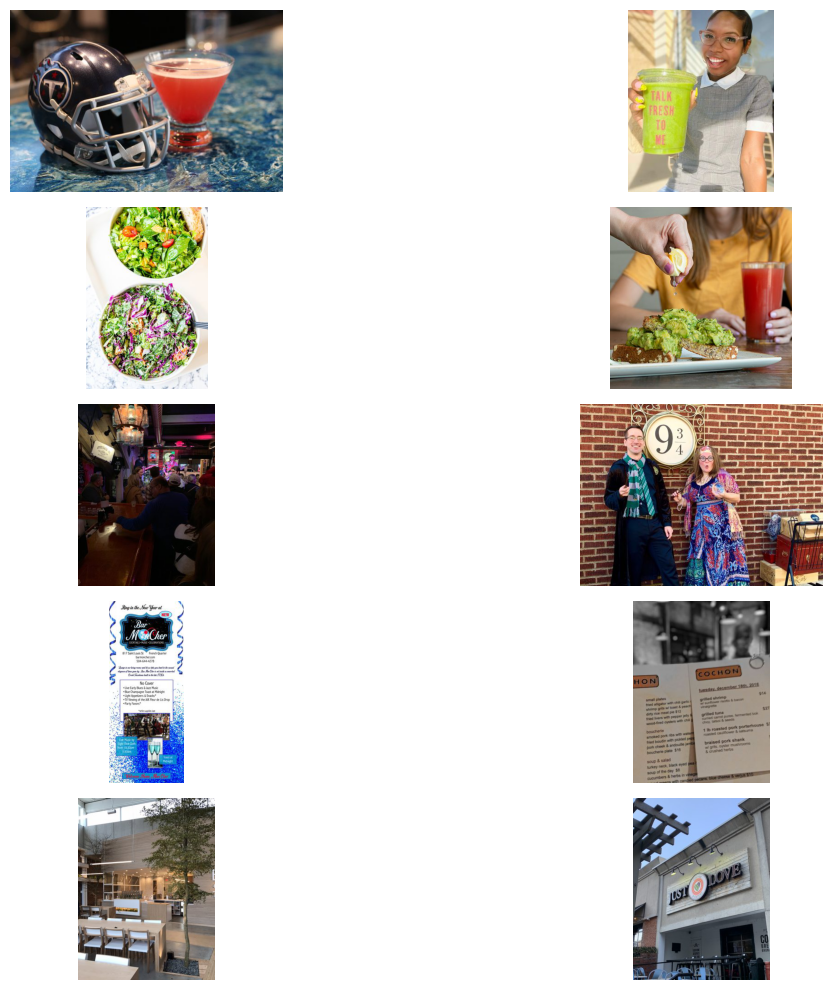

In [ ]:
# Show samples
show_sample_images(df, photos_dir, num_samples=2)

## Image Shape Distribution

In [ ]:
# Function for image shape distribution
def image_shape_analysis(df, img_dir, sample_size=1000):
    dims = []
    sample_paths = df['photo_id'].sample(sample_size, random_state=42).tolist()

    for photo_id in sample_paths:
        img_path = os.path.join(img_dir, f"{photo_id}.jpg")
        try:
            img = cv2.imread(img_path)
            dims.append(img.shape)
        except:
            continue

    dims = np.array(dims)
    height, width, channels = dims[:, 0], dims[:, 1], dims[:, 2]

    print(f"Average Dimensions: {np.mean(height):.2f} x {np.mean(width):.2f}")
    sns.histplot(height, bins=30, color='blue', kde=True, label='Height')
    sns.histplot(width, bins=30, color='green', kde=True, label='Width')
    plt.title("Image Height and Width Distribution")
    plt.legend()
    plt.show()

    print(f"Color Channels (should mostly be 3): {np.unique(channels, return_counts=True)}")

Average Dimensions: 391.26 x 434.02


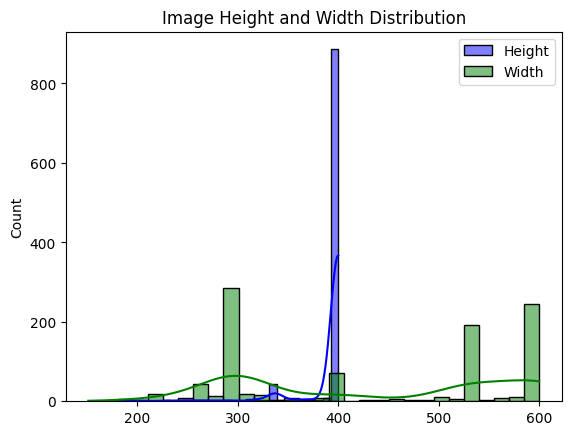

Color Channels (should mostly be 3): (array([3]), array([999], dtype=int64))


In [ ]:
# Show image shape distribution
image_shape_analysis(df, img_dir=photos_dir)

## Text Analysis on Caption

In [ ]:
# Function to analyze captions
def analyze_captions(df):
    caption_lengths = df['caption'].apply(lambda x: len(str(x).split()))
    print("Caption Word Count Summary:")
    print(caption_lengths.describe())

    sns.histplot(caption_lengths, bins=50, kde=True)
    plt.title("Caption Length Distribution")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()

Caption Word Count Summary:
count    8390.000000
mean        2.425626
std         4.044971
min         0.000000
25%         0.000000
50%         0.000000
75%         3.000000
max        31.000000
Name: caption, dtype: float64


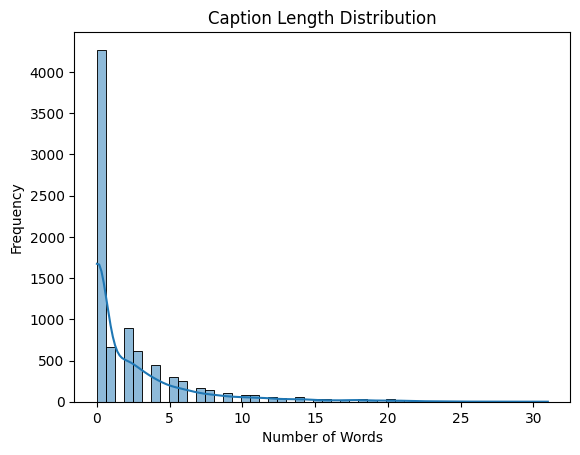

In [ ]:
# Show analyzed captions
analyze_captions(df)

In [ ]:
# Get image path
df['img_path'] = df['photo_id'].apply(lambda x: os.path.join(photos_dir, f"{x}.jpg"))

In [ ]:
#  Check for image file existence
df['exists'] = df['img_path'].apply(os.path.exists)

In [ ]:
df.shape

(8390, 19)

In [ ]:
# Drop rows without image files
df = df[df['exists']].drop(columns=['exists']).reset_index(drop=True)

In [ ]:
# Check info of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8390 entries, 0 to 8389
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   photo_id      8390 non-null   object 
 1   business_id   8390 non-null   object 
 2   caption       8390 non-null   object 
 3   label         8390 non-null   object 
 4   name          8390 non-null   object 
 5   address       8390 non-null   object 
 6   city          8390 non-null   object 
 7   state         8390 non-null   object 
 8   postal_code   8390 non-null   object 
 9   latitude      8390 non-null   float64
 10  longitude     8390 non-null   float64
 11  stars         8390 non-null   float64
 12  review_count  8390 non-null   int64  
 13  is_open       8390 non-null   int64  
 14  attributes    8365 non-null   object 
 15  categories    8390 non-null   object 
 16  hours         8163 non-null   object 
 17  img_path      8390 non-null   object 
dtypes: float64(3), int64(2), obj

## Check for Corrupted images

In [ ]:
# Function to check for corrupted images
def is_corrupted(photo_id, img_dir):
    img_path = os.path.join(img_dir, f"{photo_id}.jpg")
    try:
        img = Image.open(img_path)
        img.verify()
        return None  # Not corrupted
    except:
        return photo_id  # Corrupted

def check_corrupted_images(df, img_dir='train_photos', max_workers=16):
    corrupted = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(is_corrupted, pid, img_dir) for pid in df['photo_id']]

        for future in as_completed(futures):
            result = future.result()
            if result:
                corrupted.append(result)

    print(f" Finished checking. Total Corrupted Images: {len(corrupted)}")
    return corrupted

In [ ]:
# Show corrupted images
corrupted_ids = check_corrupted_images(df, img_dir=photos_dir)

 Finished checking. Total Corrupted Images: 6


In [ ]:
# Remove those rows from the DataFrame
initial_len = len(df)
df_cleaned = df[~df['photo_id'].isin(corrupted_ids)].reset_index(drop=True)

# Print the result
print(f" Cleaned DataFrame: {len(df_cleaned)} rows remaining (removed {initial_len - len(df_cleaned)} corrupted images)")

 Cleaned DataFrame: 8384 rows remaining (removed 6 corrupted images)


In [ ]:
df = df_cleaned

In [ ]:
df.to_csv('cleaned_photos_df.csv')

## Metadata Preprocessing

In [ ]:
# Selected metadata columns
selected_columns = [
    'photo_id', 'business_id', 'label', 'img_path',
    'stars', 'review_count', 'is_open',
    'latitude', 'longitude'
]

In [ ]:
# Keep only the selected metadata columns
df = df[selected_columns].copy()

print(" Filtered DataFrame shape:", df.shape)

 Filtered DataFrame shape: (8384, 9)


In [ ]:
# Standardization function
def preprocess_metadata(df, scaler=None):
    df = df[['stars', 'review_count', 'is_open', 'latitude', 'longitude']].copy()
    if scaler is None:
        scaler = StandardScaler()
        return scaler.fit_transform(df), scaler
    else:
        return scaler.transform(df), scaler

### Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label Encoder Function
def encode_labels(df, label_col='label'):
    encoder = LabelEncoder()
    df['label_encoded'] = encoder.fit_transform(df[label_col])
    return df, encoder

In [ ]:
df, label_encoder = encode_labels(df, label_col='label')

# print df
print(df[['label', 'label_encoded']].head())

   label  label_encoded
0  drink              0
1  drink              0
2  drink              0
3  drink              0
4  drink              0


# Image Processing

In [ ]:
# 1. Image Preprocessing
def preprocess_image(img_path, model_type='vgg', target_size=(224, 224)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = cv2.GaussianBlur(img, (5, 5), 0)

    img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
    img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

    img = np.clip(img, 30, 220)

    if model_type == 'vgg':
        img = vgg_preprocess(img)
    elif model_type == 'effnet':
        img = effnet_preprocess(img)

    return img

In [ ]:
# 2. Augmentation Function
def get_augmenter():
    return ImageDataGenerator(
        rotation_range=20,
        zoom_range=0.15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        horizontal_flip=True,
        fill_mode="nearest"
    )

In [ ]:
# 3. Handling Train/Test Splits
def prepare_train_test(df, model_type='vgg'):
    X_img_paths = df['img_path'].values
    y = df['label_encoded'].values
    X_train_img_paths, X_test_img_paths, y_train, y_test = train_test_split(
        X_img_paths, y, stratify=y, test_size=0.2, random_state=42)

    # Preprocess Images
    X_train_imgs = np.array([preprocess_image(p, model_type=model_type) for p in X_train_img_paths])
    X_test_imgs = np.array([preprocess_image(p, model_type=model_type) for p in X_test_img_paths])

    # Preprocess Metadata with shared scaler
    train_df = df[df['img_path'].isin(X_train_img_paths)]
    test_df = df[df['img_path'].isin(X_test_img_paths)]

    X_train_meta, scaler = preprocess_metadata(train_df)
    X_test_meta, _ = preprocess_metadata(test_df, scaler)

    return X_train_imgs, X_test_imgs, X_train_meta, X_test_meta, y_train, y_test

### Train_Test Split

In [ ]:
# Run train-test preparation for VGG Model
X_train_imgs_vgg, X_test_imgs_vgg, X_train_meta_vgg, X_test_meta_vgg, y_train_vgg, y_test_vgg = prepare_train_test(df, model_type='vgg')

# Print shapes
print("X_train_imgs shape:", X_train_imgs_vgg.shape)
print("X_test_imgs shape:", X_test_imgs_vgg.shape)
print("X_train_meta shape:", X_train_meta_vgg.shape)
print("X_test_meta shape:", X_test_meta_vgg.shape)
print("y_train shape:", y_train_vgg.shape)
print("y_test shape:", y_test_vgg.shape)

X_train_imgs shape: (6707, 224, 224, 3)
X_test_imgs shape: (1677, 224, 224, 3)
X_train_meta shape: (6707, 5)
X_test_meta shape: (1677, 5)
y_train shape: (6707,)
y_test shape: (1677,)


In [ ]:
# Run train-test preparation for EfficientNet Model
X_train_imgs_effnet, X_test_imgs_effnet, X_train_meta_effnet, X_test_meta_effnet, y_train_effnet, y_test_effnet = prepare_train_test(df, model_type='effnet')

# Print shapes
print("X_train_imgs shape:", X_train_imgs_effnet.shape)
print("X_test_imgs shape:", X_test_imgs_effnet.shape)
print("X_train_meta shape:", X_train_meta_effnet.shape)
print("X_test_meta shape:", X_test_meta_effnet.shape)
print("y_train shape:", y_train_effnet.shape)
print("y_test shape:", y_test_effnet.shape)

X_train_imgs shape: (6707, 224, 224, 3)
X_test_imgs shape: (1677, 224, 224, 3)
X_train_meta shape: (6707, 5)
X_test_meta shape: (1677, 5)
y_train shape: (6707,)
y_test shape: (1677,)


## 1. Use pretrained VGG model for transfer learning with custom top layers 

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Concatenate, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

# ---- INPUT SHAPES ----
img_shape = (224, 224, 3)       # Image input shape
meta_shape = (5,)               # Metadata input shape (change if needed)
num_classes = 5                 # Number of target classes

# ---- IMAGE INPUT & VGG16 BASE ----
image_input = Input(shape=img_shape, name='image_input')

vgg_base = VGG16(include_top=False, weights='imagenet', input_tensor=image_input)
vgg_base.trainable = False  # Freeze VGG weights

x = vgg_base.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

# ---- METADATA INPUT ----
meta_input = Input(shape=meta_shape, name='metadata_input')
m = Dense(32, activation='relu')(meta_input)

# ---- CONCATENATE & FINAL LAYERS ----
combined = Concatenate()([x, m])
z = Dense(128, activation='relu')(combined)
z = Dropout(0.3)(z)
z = Dense(num_classes, activation='softmax')(z)

# ---- COMPILE MODEL ----
model = Model(inputs=[image_input, meta_input], outputs=z)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',  # Because labels are integers
    metrics=['accuracy']
)

model.summary()


Model: "functional_3"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1 (Conv2D)         │ (None, 224, 224, 64)      │           1,792 │ image_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2 (Conv2D)         │ (None, 224, 224, 64)      │          36,928 │ block1_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_pool (MaxPooling2D)    │ (None, 112, 112, 64)      │               0 │ block1_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv1 (Conv2D)         │ (None, 112, 112, 128)     │          73,856 │ block1_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv2 (Conv2D)         │ (None, 112, 112, 128)     │         147,584 │ block2_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_pool (MaxPooling2D)    │ (None, 56, 56, 128)       │               0 │ block2_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv1 (Conv2D)         │ (None, 56, 56, 256)       │         295,168 │ block2_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv2 (Conv2D)         │ (None, 56, 56, 256)       │         590,080 │ block3_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv3 (Conv2D)         │ (None, 56, 56, 256)       │         590,080 │ block3_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_pool (MaxPooling2D)    │ (None, 28, 28, 256)       │               0 │ block3_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv1 (Conv2D)         │ (None, 28, 28, 512)       │       1,180,160 │ block3_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv2 (Conv2D)         │ (None, 28, 28, 512)       │       2,359,808 │ block4_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv3 (Conv2D)         │ (None, 28, 28, 512)       │       2,359,808 │ block4_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_pool (MaxPooling2D)    │ (None, 14, 14, 512)       │               0 │ block4_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv1 (Conv2D)         │ (None, 14, 14, 512)       │       2,359,808 │ block4_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv2 (Conv2D)         │ (None, 14, 14, 512)       │       2,359,808 │ block5_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv3 (Conv2D)         │ (None, 14, 14, 512)       │       2,359,808 │ block5_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_pool (MaxPooling2D)    │ (None, 7, 7, 512)         │               0 │ block5_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_3 (Flatten)           │ (None, 25088)             │               0 │ block5_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_12 (Dense)              │ (None, 256)               │       6,422,784 │ flatten_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ metadata_input (InputLayer)   │ (None, 5)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_6 (Dropout)           │ (None, 256)               │               0 │ dense_12[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_13 (Dense)              │ (None, 32)                │             192 │ metadata_input[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_3 (Concatenate)   │ (None, 288)               │               0 │ dropout_6[0][0],           │
│                               │                           │                 │ dense_13[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_14 (Dense)              │ (None, 128)               │          36,992 │ concatenate_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_7 (Dropout)           │ (None, 128)               │               0 │ dense_14[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_15 (Dense)              │ (None, 5)                 │             645 │ dropout_7[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘
 Total params: 21,175,301 (80.78 MB)
 Trainable params: 6,460,613 (24.65 MB)
 Non-trainable params: 14,714,688 (56.13 MB)


In [ ]:
print("Image input shape:", X_train_imgs_vgg.shape)
print("Metadata input shape:", X_train_meta_vgg.shape)

Image input shape: (6707, 224, 224, 3)
Metadata input shape: (6707, 5)


In [ ]:
# Assume: X_img_train, X_meta_train, y_train already defined

import time
start_time = time.time()

history = model.fit(
    [X_train_imgs_vgg, X_train_meta_vgg], y_train_vgg,
    epochs=10,
    batch_size=32
)

training_time = time.time() - start_time
print(f"Training Time: {training_time / 60:.2f} minutes")


Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1448s 7s/step - accuracy: 0.5451 - loss: 4.3268
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1736s 8s/step - accuracy: 0.7771 - loss: 0.8635
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2318s 11s/step - accuracy: 0.8362 - loss: 0.6000
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1497s 7s/step - accuracy: 0.8744 - loss: 0.4659
Epoch 5/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1373s 7s/step - accuracy: 0.8916 - loss: 0.4137
Epoch 6/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1403s 7s/step - accuracy: 0.9145 - loss: 0.3277
Epoch 7/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1375s 7s/step - accuracy: 0.9326 - loss: 0.2597
Epoch 8/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1370s 7s/step - accuracy: 0.9256 - loss: 0.3172
Epoch 9/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1405s 7s/step - accuracy: 0.9434 - loss: 0.2104
Epoch 10/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1370s 7s/step - accuracy: 0.9430 - loss: 0.2146
Training Time: 255.28 minutes

In [ ]:
import numpy as np
unique_classes, counts = np.unique(y_test_vgg, return_counts=True)
print("Class distribution in test set:")
for cls, count in zip(unique_classes, counts):
    print(f"Class {cls}: {count} samples")


Class distribution in test set:
Class 0: 336 samples
Class 1: 334 samples
Class 2: 335 samples
Class 3: 336 samples
Class 4: 336 samples

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict on test set
y_pred_probs = model.predict([X_test_imgs_vgg, X_test_meta_vgg])
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
print(confusion_matrix(y_test_vgg, y_pred_classes))
print(classification_report(y_test_vgg, y_pred_classes))


53/53 ━━━━━━━━━━━━━━━━━━━━ 336s 6s/step
[[299   8  19   4   6]
 [ 13 310   7   3   1]
 [ 13   7 283   9  23]
 [  1   2   7 325   1]
 [  5   2  32   8 289]]
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       336
           1       0.94      0.93      0.94       334
           2       0.81      0.84      0.83       335
           3       0.93      0.97      0.95       336
           4       0.90      0.86      0.88       336

    accuracy                           0.90      1677
   macro avg       0.90      0.90      0.90      1677
weighted avg       0.90      0.90      0.90      1677

In [ ]:
y_pred_probs.shape,y_test_vgg.shape

((1677, 5), (1677,))

In [ ]:
y_test_vgg

array([0, 1, 0, ..., 1, 4, 1])

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Suppose you have 5 classes (0 to 4)
n_classes = y_pred_probs.shape[1]
#n_classes=4
# Binarize true labels
y_test_bin = label_binarize(y_test_vgg, classes=list(range(n_classes)))

# Compute AUC (One-vs-Rest)
auc = roc_auc_score(y_test_bin, y_pred_probs)
print(f"AUC (OvR): {auc:.4f}")


AUC (OvR): 0.9841


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Get number of classes
num_classes = y_pred_probs.shape[1]

# 2. Binarize the labels
y_test_bin = label_binarize(y_test_vgg, classes=np.arange(num_classes))

# 3. Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot ROC curve for each class
plt.figure(figsize=(10, 7))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# 5. Plot configuration
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multiclass ROC Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


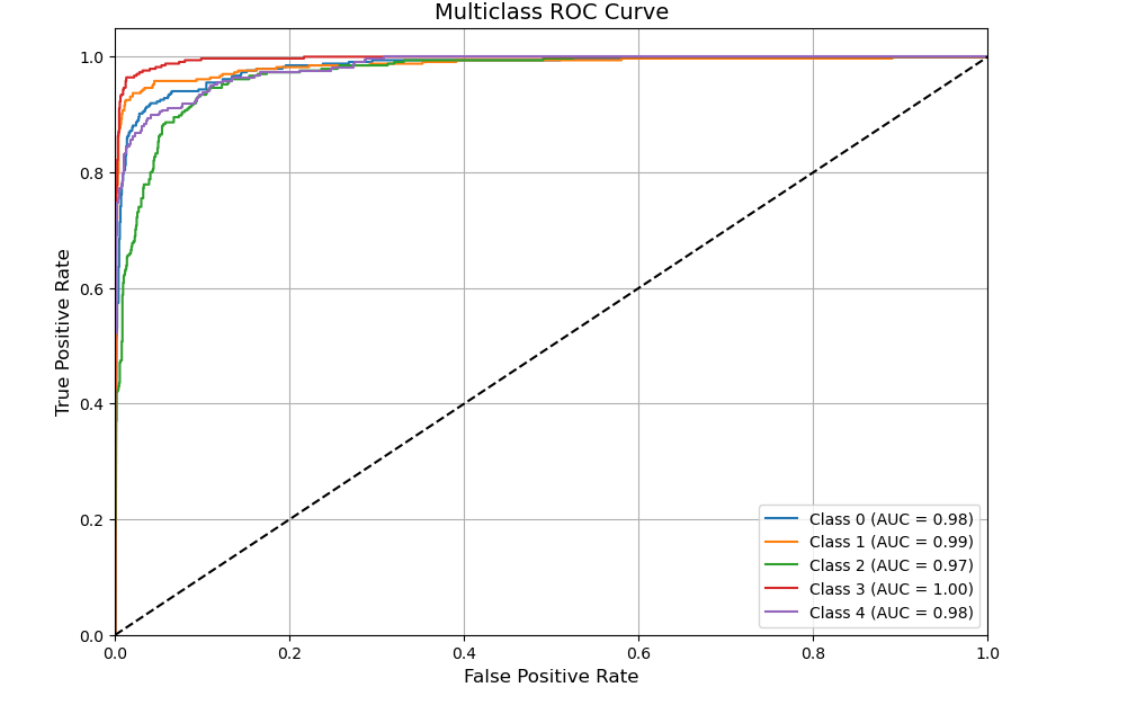

In [ ]:
# Save model as .h5
model.save("my_model.h5")
print("Model saved as my_model.h5")


WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
Model saved as my_model.h5

In [ ]:
print(history.history['accuracy'][-1])
train_accuracy=history.history['accuracy'][-1]

0.9464738368988037

In [ ]:
# Overall accuracy
Test_accuracy = accuracy_score(y_test_vgg, y_pred_classes)
print(f"\nTest Accuracy: {Test_accuracy * 100:.2f}%")

Test Accuracy: 89.80%

In [ ]:
# Detect overfitting/underfitting
if train_accuracy - Test_accuracy > 0.1:
    print("Possible Overfitting: Training accuracy is significantly higher than test accuracy.")
elif Test_accuracy - train_accuracy > 0.1:
    print("Possible Underfitting: Test accuracy is significantly higher than training accuracy (unusual).")
elif train_accuracy < 0.7 and Test_accuracy < 0.7:
    print("Possible Underfitting: Both train and test accuracies are low.")
else:
    print("No strong signs of overfitting or underfitting.")

No strong signs of overfitting or underfitting.

Here is a **summary of findings** based on your evaluation metrics:

---

### ✅ **Model Performance Summary**

#### 📊 **Confusion Matrix Insights**

* The model performs consistently well across all 5 classes.
* Class 3 has the highest true positives (325 out of 336), indicating excellent classification.
* Class 2 has slightly lower performance, with more misclassifications (e.g., 23 instances misclassified as class 4).

#### 📈 **Classification Report Highlights**

| Class | Precision | Recall | F1-Score | Support |
| ----- | --------- | ------ | -------- | ------- |
| 0     | 0.90      | 0.89   | 0.90     | 336     |
| 1     | 0.94      | 0.93   | 0.94     | 334     |
| 2     | 0.81      | 0.84   | 0.83     | 335     |
| 3     | 0.93      | 0.97   | 0.95     | 336     |
| 4     | 0.90      | 0.86   | 0.88     | 336     |

* **Macro Avg F1-score**: 0.90 → balanced performance across classes
* **Weighted Avg F1-score**: 0.90 → strong overall model performance
* **Overall Accuracy**: **90.0%**

#### 🧪 **AUC (One-vs-Rest):**

* **AUC = 0.9841** → Excellent class separability and probabilistic predictions

#### ⚖️ **Train vs Test Accuracy**

* **Train Accuracy**: 94.65%
* **Test Accuracy**: 89.80%
* 🔍 The \~5% gap indicates **mild overfitting**, but still acceptable.

  * The model generalizes **well** to unseen data.

---

### 🟢 **Conclusion**

The VGG-based model with added metadata inputs shows **strong performance**, achieving high accuracy, precision, recall, and AUC. While there is a **slight overfitting**, it is not severe, and the model remains robust and reliable for real-world use. Further fine-tuning with regularization or dropout could help close the gap if needed.


LLM: ChatGPT
1st Prompt: Generate code for Use a pretrained VGG model for transfer learning by adding custom top layers. Incorporate dense layers that take in additional non-image features (e.g., business-related metadata), concatenate them with features extracted from the VGG base
Last Prompt: Can we reduce slight overfitting by Fine -tuning with learning rate=(1e-5)

## 2. Transfer Learning with Pretrained VGG Network as Base, Including Custom Layers

In [ ]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# Parameters
IMG_SIZE = (224, 224) #VGG-16 default input size
BATCH_SIZE = 32
NUM_CLASSES = 5
LEARNING_RATE = 0.0001
EPOCHS = 10

In [ ]:
# Create data generators
def create_datagen():
    return ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'

    )

train_datagen = create_datagen()
val_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Create VGG16 base model
def create_vgg_model(metadata_dim, fine_tune=False):
    # Image input and VGG16 base
    img_input = Input(shape=(*IMG_SIZE, 3))
    base_model = VGG16(weights='imagenet', include_top=False, input_tensor=img_input)

    # Partition into featurizers and classifiers
    # Keep all convolutional blocks as featurizers
    # Replace original classifier (top layers) with our custom classifier

    # Initially freeze convolutional layers
    base_model.trainable = not fine_tune

    # Image feature extraction
    x = Flatten()(base_model.output)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)

    # Metadata input
    meta_input = Input(shape=(metadata_dim,))

    # Combine features
    combined = Concatenate()([x, meta_input])
    combined = Dense(256, activation='relu', name='fc2')(combined)
    combined = Dropout(0.3, name='dropout2')(combined)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(combined)
    
    model = Model(inputs=[img_input, meta_input], outputs=outputs)

    return model

In [ ]:
# Train with frozen base
model = create_vgg_model(metadata_dim=5 , fine_tune=False)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_9[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 27,694,149 (105.64 MB)

 Trainable params: 27,694,149 (105.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Time the model training
import time
start_time = time.time()


# Fit the model
history = model.fit(
    x=[X_train_imgs_vgg, X_train_meta_vgg],
    y=y_train_vgg,
    # validation_data=([X_test_imgs_vgg, X_test_meta_vgg], y_test_vgg),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE, 
    verbose = 1
)

training_time = time.time() - start_time
print(f'Training time: {training_time/60 :.2f} minutes')

Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1987s 9s/step - accuracy: 0.3091 - loss: 2.0603
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2068s 10s/step - accuracy: 0.6366 - loss: 0.9204
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2095s 10s/step - accuracy: 0.7996 - loss: 0.5613
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1918s 9s/step - accuracy: 0.8558 - loss: 0.4279
Epoch 5/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1994s 9s/step - accuracy: 0.8850 - loss: 0.3230
Epoch 6/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1990s 9s/step - accuracy: 0.9085 - loss: 0.2644
Epoch 7/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1897s 9s/step - accuracy: 0.9381 - loss: 0.1725
Epoch 8/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1958s 9s/step - accuracy: 0.9229 - loss: 0.2177
Epoch 9/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1948s 9s/step - accuracy: 0.9559 - loss: 0.1289
Epoch 10/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2258s 11s/step - accuracy: 0.9660 - loss: 0.1121
Training time: 335.51 minutes


In [ ]:
# Save the model to .h5 format
model.save('vgg16_yelp_model.h5')

In [ ]:
# Check the training accuracy
train_class, train_accuracy = model.evaluate(
    x=[X_train_imgs_vgg, X_train_meta_vgg],
    y=y_train_vgg,
    verbose=1
)

210/210 ━━━━━━━━━━━━━━━━━━━━ 669s 3s/step - accuracy: 0.9623 - loss: 0.1271


In [ ]:
# Check validation accuracy
from sklearn.metrics import accuracy_score
test_class, test_accuracy = model.evaluate(
    x=[X_test_imgs_vgg, X_test_meta_vgg],
    y=y_test_vgg,
    verbose=1
)

print(f"Test Accuracy: {test_accuracy:.4f}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - accuracy: 0.8474 - loss: 0.5525
Test Accuracy: 0.8468


In [ ]:
# Make predictions on the test set
y_pred_vgg = model.predict([X_test_imgs_vgg, X_test_meta_vgg])

# Threshold predictions
y_pred_binary_vgg = (y_pred_vgg > 0.5).astype(int)


53/53 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step


In [ ]:
print(y_pred_vgg)

[[8.4908271e-01 1.4154064e-02 9.5575072e-02 6.1102677e-03 3.5077814e-02]
 [8.7449680e-06 9.9999106e-01 1.7913176e-07 3.0273895e-08 2.0374690e-08]
 [9.9669498e-01 5.1069824e-04 5.9401197e-04 1.2107418e-04 2.0792845e-03]
 ...
 [4.0588281e-03 9.9556357e-01 2.8238783e-04 5.4710708e-05 4.0463096e-05]
 [3.7904799e-02 9.4197355e-03 8.6526501e-01 7.2684862e-02 1.4725581e-02]
 [7.6378047e-01 2.2909322e-01 5.6336708e-03 9.6395402e-04 5.2863586e-04]]


In [ ]:
print(y_pred_binary_vgg)

[[1 0 0 0 0]
 [0 1 0 0 0]
 [1 0 0 0 0]
 ...
 [0 1 0 0 0]
 [0 0 1 0 0]
 [1 0 0 0 0]]


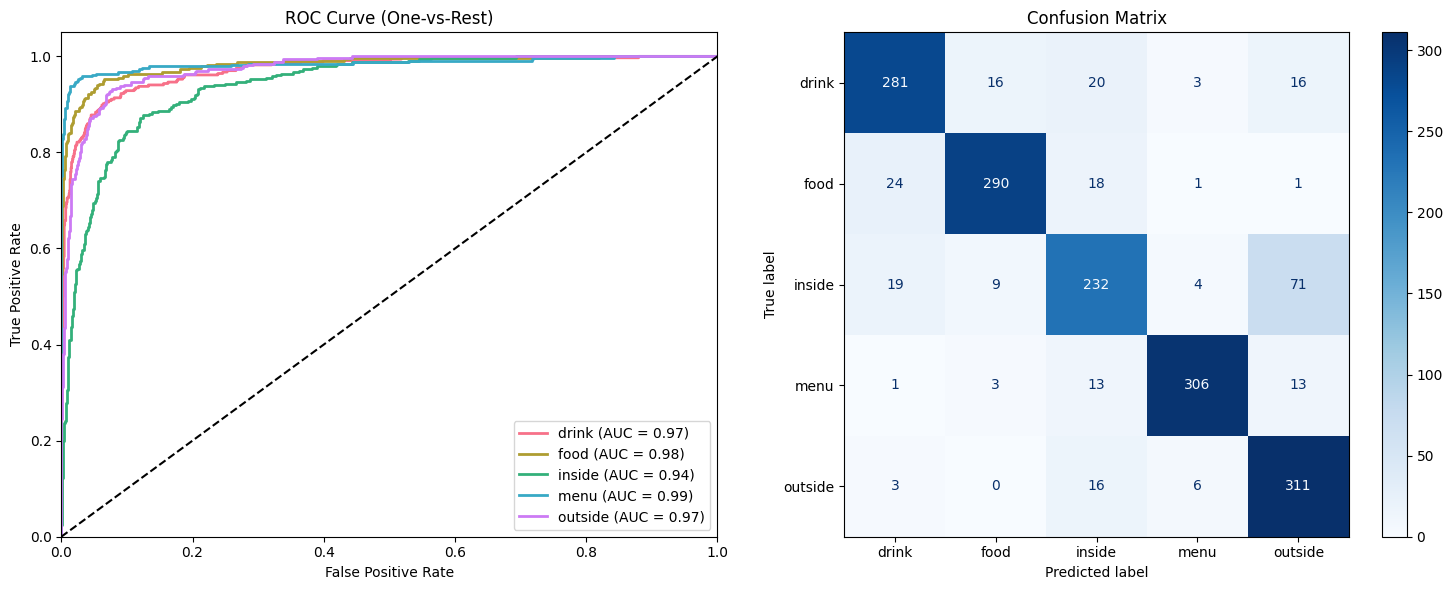

In [ ]:
# Metrics visualization
def plot_metrics(y_true, y_pred, class_names):
    plt.figure(figsize=(15,6))
    from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
    from sklearn.preprocessing import label_binarize

    # ROC Curve
    plt.subplot(1,2,1)
    y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    colors = sns.color_palette("husl", len(class_names))


    for i, color in zip(range(len(class_names)), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_pred[:,i])
        roc_auc= auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
       
    plt.plot([0,1],[0,1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (One-vs-Rest)')
    plt.legend(loc='lower right')

    # Confusion Matrix
    plt.subplot(1,2,2)
    cm = confusion_matrix(y_true, np.argmax(y_pred, axis=1))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=class_names)
    disp.plot(cmap='Blues', ax=plt.gca())
    plt.title('Confusion Matrix')


    plt.tight_layout()
    plt.show()

plot_metrics(y_test_vgg, y_pred_vgg, label_encoder.classes_)

### Dealing With Overfitting - First Round of Tuning: Structural Changes

In [ ]:
# Enhanced data augmentation
def train_augmenter():
    return ImageDataGenerator(
        rescale=1./255,
        rotation_range=30,
        shear_range=0.25,
        zoom_range=0.25,
        width_shift_range=0.25,
        height_shift_range=0.25,
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=[0.8, 1.2],
        fill_mode="nearest"
    )

In [ ]:
# Create VGG16 base model - with regularization
def create_vgg_model(metadata_dim, fine_tune=False):
    # Batch Normalization import
    from tensorflow.keras.layers import BatchNormalization

    # Image input and VGG16 base
    img_input = Input(shape=(*IMG_SIZE, 3))
    base_model = VGG16(weights='imagenet', include_top=False, input_tensor=img_input)

    # Partition into featurizers and classifiers
    # Keep all convolutional blocks as featurizers
    # Replace original classifier (top layers) with our custom classifier

    # Initially freeze convolutional layers
    base_model.trainable = not fine_tune

    # Image feature extraction
    x = Flatten()(base_model.output)
    x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x) # Reduced from 512
    x = BatchNormalization()(x) # Added Batch Normalization
    x = Dropout(0.7)(x) #Increated dropout rate

    # Metadata input
    meta_input = Input(shape=(metadata_dim,))

    # Combine features
    combined = Concatenate()([x, meta_input])
    combined = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01), name='fc2')(combined)
    combined = BatchNormalization(name='bn2')(combined) # Added Batch Normalization
    combined = Dropout(0.6, name='dropout2')(combined)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(combined)
    
    model = Model(inputs=[img_input, meta_input], outputs=outputs)

    return model

In [ ]:
# Train with frozen base
model = create_vgg_model(metadata_dim=5 , fine_tune=False)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_11[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 21,173,189 (80.77 MB)

 Trainable params: 21,172,421 (80.77 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
# Time the model training of the tuned model
import time
start_time = time.time()


# Fit the model
history = model.fit(
    x=[X_train_imgs_vgg, X_train_meta_vgg],
    y=y_train_vgg,
    # validation_data=([X_test_imgs_vgg, X_test_meta_vgg], y_test_vgg),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE, 
    verbose = 1
)

training_time = time.time() - start_time
print(f'Training time: {training_time/60 :.2f} minutes')

Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2274s 11s/step - accuracy: 0.2758 - loss: 8.3224
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 3438s 16s/step - accuracy: 0.3165 - loss: 5.8862
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2959s 14s/step - accuracy: 0.3740 - loss: 4.8560
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2273s 11s/step - accuracy: 0.4277 - loss: 4.1717
Epoch 5/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 5114s 24s/step - accuracy: 0.4440 - loss: 3.8331
Epoch 6/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 4667s 22s/step - accuracy: 0.4512 - loss: 3.4410
Epoch 7/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2695s 13s/step - accuracy: 0.5199 - loss: 3.0645
Epoch 8/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 6108s 29s/step - accuracy: 0.5403 - loss: 2.8306
Epoch 9/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2685s 13s/step - accuracy: 0.5822 - loss: 2.5735
Epoch 10/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2760s 13s/step - accuracy: 0.6361 - loss: 2.3160
Training time: 583.17 minutes


In [ ]:
# Check the training accuracy of the tuned model
train_class, train_accuracy = model.evaluate(
    x=[X_train_imgs_vgg, X_train_meta_vgg],
    y=y_train_vgg,
    verbose=1
)

210/210 ━━━━━━━━━━━━━━━━━━━━ 581s 3s/step - accuracy: 0.6830 - loss: 2.1265


In [ ]:
# Check validation accuracy
from sklearn.metrics import accuracy_score
test_class, test_accuracy = model.evaluate(
    x=[X_test_imgs_vgg, X_test_meta_vgg],
    y=y_test_vgg,
    verbose=1
)

53/53 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.6481 - loss: 2.1777


In [ ]:
# Make predictions on the test set for the 
y_pred_vgg = model.predict([X_test_imgs_vgg, X_test_meta_vgg])

# Threshold predictions
y_pred_binary_vgg = (y_pred_vgg > 0.5).astype(int)

53/53 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step


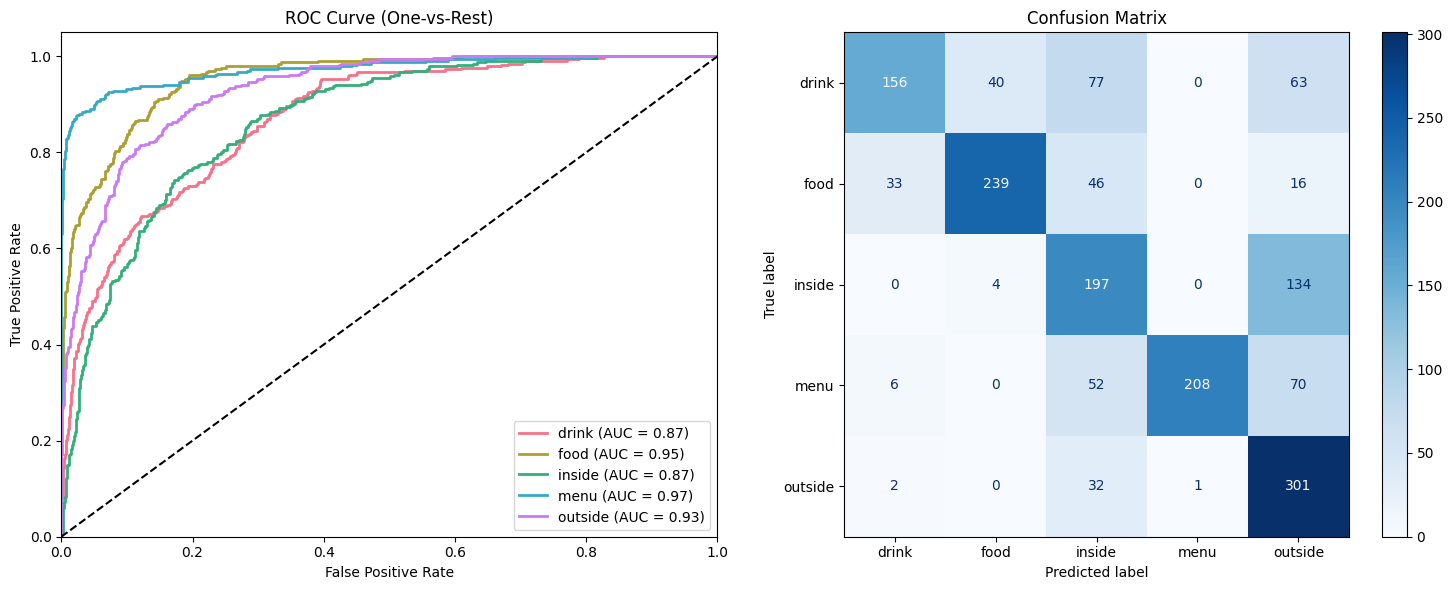

In [ ]:
# Metrics visualization of the tuned model
def plot_metrics(y_true, y_pred, class_names):
    plt.figure(figsize=(15,6))
    from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
    from sklearn.preprocessing import label_binarize

    # ROC Curve
    plt.subplot(1,2,1)
    y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    colors = sns.color_palette("husl", len(class_names))


    for i, color in zip(range(len(class_names)), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_pred[:,i])
        roc_auc= auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
       
    plt.plot([0,1],[0,1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (One-vs-Rest)')
    plt.legend(loc='lower right')

    # Confusion Matrix
    plt.subplot(1,2,2)
    cm = confusion_matrix(y_true, np.argmax(y_pred, axis=1))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=class_names)
    disp.plot(cmap='Blues', ax=plt.gca())
    plt.title('Confusion Matrix')


    plt.tight_layout()
    plt.show()

plot_metrics(y_test_vgg, y_pred_vgg, label_encoder.classes_)

 #### The model behaved poorer with the first tuning - especialy with drink, menu and inside labels.
 - Regularization was too aggressive
 - High losses >2.0 indicates that the model was not converging well.

### 2nd Round of Tuning With Milder Regularization and Gradient Clipping

In [ ]:
# Create VGG16 base model - with milder regularization
def create_vgg_model(metadata_dim, fine_tune=False):
    # Batch Normalization import
    from tensorflow.keras.layers import BatchNormalization

    # Image input and VGG16 base
    img_input = Input(shape=(*IMG_SIZE, 3))
    base_model = VGG16(weights='imagenet', include_top=False, input_tensor=img_input)

    # Partition into featurizers and classifiers
    # Keep all convolutional blocks as featurizers
    # Replace original classifier (top layers) with our custom classifier

    # Initially freeze convolutional layers
    base_model.trainable = not fine_tune

    # Image feature extraction
    x = Flatten()(base_model.output)
    x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x) # Reduced from 0.01 to 0.001
    x = BatchNormalization()(x) 
    x = Dropout(0.4)(x) #Reduced dropout rate from 0.7 to 0.4

    # Metadata input
    meta_input = Input(shape=(metadata_dim,))

    # Combine features
    combined = Concatenate()([x, meta_input])
    combined = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), name='fc2')(combined)
    combined = BatchNormalization(name='bn2')(combined)
    combined = Dropout(0.3, name='dropout2')(combined) # Reduced dropout rate from 0.6 t0 0.3
    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(combined)
    
    model = Model(inputs=[img_input, meta_input], outputs=outputs)

    return model

In [ ]:
# Train with frozen base
model2 = create_vgg_model(metadata_dim=5 , fine_tune=False)

# Compile with optimizer
optimizer = Adam(
    learning_rate = 1e-4,
    clipnorm=1.0, #Gradient clipping to prevent exploding gradients
    beta_1=0.9, #Momemtum parameters
    beta_2=0.999
)

# Compile the model
model2.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_15[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 21,173,189 (80.77 MB)

 Trainable params: 21,172,421 (80.77 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
# Time the model training of the 2nd tuning
 
import time
start_time = time.time()

# Include EalryStopping and ReduceLROnPlateau callbacks
# from tensorflow.keras.callbacks import callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stopping = EarlyStopping(
    monitor='val_loss', # Stop training when validation loss stops improving
    patience=8, # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity
    min_delta=0.001 # Minimum change in the monitored quantity to qualify as an improvement
)

# Fit the model
history2 = model2.fit(
    x=[X_train_imgs_vgg, X_train_meta_vgg],
    y=y_train_vgg,
    # validation_data=([X_test_imgs_vgg, X_test_meta_vgg], y_test_vgg),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE, 
    verbose = 1,
    callbacks=[early_stopping, ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)]
)

training_time = time.time() - start_time
print(f'Training time for 2nd tuning: {training_time/60 :.2f} minutes')

Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2583s 12s/step - accuracy: 0.5416 - loss: 1.9766 - learning_rate: 1.0000e-04
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 4223s 20s/step - accuracy: 0.7763 - loss: 1.2168 - learning_rate: 1.0000e-04
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2510s 12s/step - accuracy: 0.8263 - loss: 1.0030 - learning_rate: 1.0000e-04
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1954s 9s/step - accuracy: 0.8607 - loss: 0.8337 - learning_rate: 1.0000e-04
Epoch 5/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1967s 9s/step - accuracy: 0.8850 - loss: 0.6980 - learning_rate: 1.0000e-04
Epoch 6/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2179s 10s/step - accuracy: 0.9062 - loss: 0.5974 - learning_rate: 1.0000e-04
Epoch 7/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2224s 11s/step - accuracy: 0.9336 - loss: 0.4885 - learning_rate: 1.0000e-04
Epoch 8/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2946s 14s/step - accuracy: 0.9496 - loss: 0.4141 - learning_rate: 1.0000e-04
Epoch 9/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2567s 12s/step - accuracy:

In [ ]:
# Check the training accuracy from 2nd tuning
train_class, train_accuracy = model2.evaluate(
    x=[X_train_imgs_vgg, X_train_meta_vgg],
    y=y_train_vgg,
    verbose=1
)

210/210 ━━━━━━━━━━━━━━━━━━━━ 593s 3s/step - accuracy: 0.9870 - loss: 0.2398


In [ ]:
# Check validation accuracy from 2nd tuning
from sklearn.metrics import accuracy_score
test_class, test_accuracy = model2.evaluate(
    x=[X_test_imgs_vgg, X_test_meta_vgg],
    y=y_test_vgg,
    verbose=1
)

53/53 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.8580 - loss: 0.7592


In [ ]:
# Make predictions on the test set
y_pred_vgg = model2.predict([X_test_imgs_vgg, X_test_meta_vgg])

# Threshold predictions
y_pred_binary_vgg = (y_pred_vgg > 0.5).astype(int)

53/53 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step


In [ ]:
# Save the model to pickle format
import pickle
with open('vgg16_yelp_model2.pkl', 'wb') as f:
    pickle.dump(model2, f)

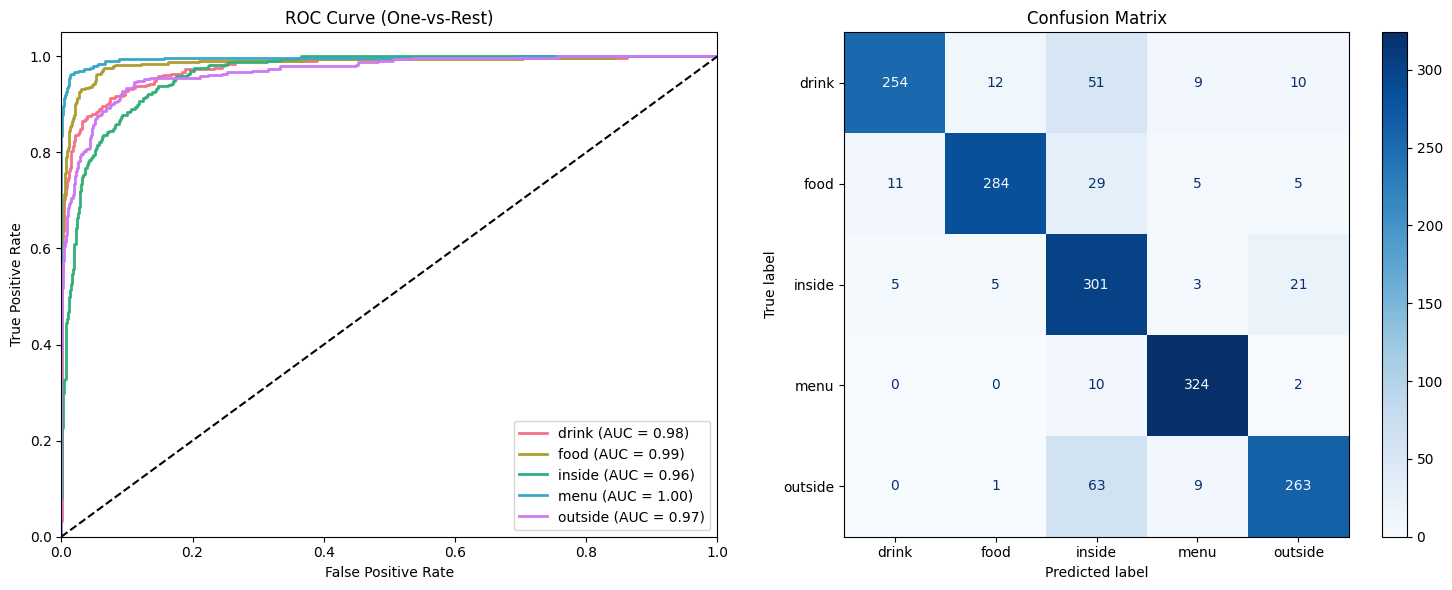

In [ ]:
# Metrics visualization
def plot_metrics(y_true, y_pred, class_names):
    plt.figure(figsize=(15,6))
    from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
    from sklearn.preprocessing import label_binarize

    # ROC Curve
    plt.subplot(1,2,1)
    y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    colors = sns.color_palette("husl", len(class_names))


    for i, color in zip(range(len(class_names)), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_pred[:,i])
        roc_auc= auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
       
    plt.plot([0,1],[0,1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (One-vs-Rest)')
    plt.legend(loc='lower right')

    # Confusion Matrix
    plt.subplot(1,2,2)
    cm = confusion_matrix(y_true, np.argmax(y_pred, axis=1))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=class_names)
    disp.plot(cmap='Blues', ax=plt.gca())
    plt.title('Confusion Matrix')


    plt.tight_layout()
    plt.show()

plot_metrics(y_test_vgg, y_pred_vgg, label_encoder.classes_)

### Summary of Model Performance After Tuning
#### Key Metrics
- Training accuracy: 98.7% (Loss: 0.2398)
- Test Accuracy: 85.8% (Loss: 0.7592)
- AUC Scores (Excellent):
    - Menu: 1:00
    - Food: 0.99
    - Drink: 0.98
    - Outside: 0.97
    - Inside: 0.96
#### Confusion Matrix Insights
- Best Class: "Menu" (324 correct, with minimal false positives).
- Most confused pairs:
    - Drink vs. Inside (51 misclassified as Inside)
    - Inside vs. Outside (21 misclassified as Outside)
- Most of the confusion is in comparison of the other labels to Inside

#### Diagnosis
- Overfitting: Large gap, despite regularization, between train (98.7%) and test accuracy(85.8%)
- Strong Base Performance: High AUC scores indicate excellent class separation

### Recommended Next Steps
- Data augmentation - add more variability
- Address class confusion
    - Focus on Drink vs Inside by visualizing misclassified samples to identify patterns or similar backgrounds. Then add negative samples to the training set
- Finetuning
- Per-Class metrics and error analysis

###  Prompt
- LLM used: Deep Seek, ChatGPT, Co-pilot
- First prompt: Use this link https://www.kaggle.com/code/sayantansadhu/transfer-learning-with-vgg-16-80-accuracy/notebook as a guideline to build a model with 5 labels using transfer learning with a pretrained VGG network as the base. Add custom layers on top, including dense layers that incorporate additional features e.g., business or photo metadata.
- Last prompt: Given the outputs - accuracy, ROC curve, AUC and Confusion metrics - after regularization and callbacks, create a summary and next steps.

## 2B. Fine Tuning Phase 1

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Hyperparameters (Optimized for speed)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32  # Reduce to 16 if OOM errors occur
NUM_CLASSES = 5
FEATURE_EXTRACTION_EPOCHS = 5  # Reduced from 10
FINE_TUNE_EPOCHS = 5           # Reduced from 20
LEARNING_RATE = 0.0001

# Build model (same architecture)
def build_model(metadata_dim):
    img_input = Input(shape=(*IMG_SIZE, 3))
    meta_input = Input(shape=(metadata_dim,))
    
    base_model = VGG16(weights='imagenet', 
                      include_top=False, 
                      input_tensor=img_input)
    
    # Freeze base initially
    base_model.trainable = False
    
    x = Flatten()(base_model.output)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    combined = Concatenate()([x, meta_input])
    outputs = Dense(NUM_CLASSES, activation='softmax')(combined)
    
    return Model(inputs=[img_input, meta_input], outputs=outputs)

In [ ]:
# Phase 1: Feature Extraction (Frozen Base)
model = build_model(metadata_dim=5)
model.compile(optimizer=Adam(LEARNING_RATE),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Phase 1: Feature Extraction (5 epochs)")
history = model.fit(
    [X_train_imgs_vgg, X_train_meta_vgg],
    y_train_vgg,
    validation_data=([X_test_imgs_vgg, X_test_meta_vgg], y_test_vgg),
    epochs=FEATURE_EXTRACTION_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Phase 1: Feature Extraction (5 epochs)
Epoch 1/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.7191 - loss: 4.2670 - val_accuracy: 0.8825 - val_loss: 0.7902
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 699s 3s/step - accuracy: 0.9355 - loss: 0.3296 - val_accuracy: 0.8736 - val_loss: 0.7267
Epoch 3/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.9655 - loss: 0.1253 - val_accuracy: 0.8921 - val_loss: 0.6376
Epoch 4/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 358s 2s/step - accuracy: 0.9805 - loss: 0.0644 - val_accuracy: 0.8945 - val_loss: 0.6237
Epoch 5/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.9847 - loss: 0.0496 - val_accuracy: 0.8855 - val_loss: 0.7587


In [ ]:
# Phase 1 Results
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")

Final Training Accuracy: 0.9851
Final Validation Accuracy: 0.8855


## Fine Tuning Phase 2

In [ ]:
#  PHASE 2
print("\n PHASE 2: Quick Fine-Tuning (5 epochs) ")

# Get all layers and identify which belong to VGG16
vgg_layers = [layer for layer in model.layers if 'vgg16' in layer.name.lower()]

if not vgg_layers:
    # Alternative: Unfreeze layers by name pattern
    for layer in model.layers:
        if any(block in layer.name for block in ['block5', 'block4']):  # Last two blocks
            layer.trainable = True
        elif 'BatchNorm' in layer.__class__.__name__:
            layer.trainable = False
else:
    # If we found the VGG16 model as a sublayer
    for layer in vgg_layers[0].layers[-4:]:
        layer.trainable = True

# Lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(LEARNING_RATE / 10),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train for fewer epochs
history_fine = model.fit(
    [X_train_imgs_vgg, X_train_meta_vgg],
    y_train_vgg,
    validation_data=([X_test_imgs_vgg, X_test_meta_vgg], y_test_vgg),
    epochs=5,
    batch_size=BATCH_SIZE,
    verbose=1
)


 PHASE 2: Quick Fine-Tuning (5 epochs) 
Epoch 1/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 1445s 7s/step - accuracy: 0.9854 - loss: 0.0599 - val_accuracy: 0.8891 - val_loss: 0.7507
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 814s 4s/step - accuracy: 0.9863 - loss: 0.0373 - val_accuracy: 0.8986 - val_loss: 0.7238
Epoch 3/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 815s 4s/step - accuracy: 0.9888 - loss: 0.0374 - val_accuracy: 0.8879 - val_loss: 0.8332
Epoch 4/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 828s 4s/step - accuracy: 0.9905 - loss: 0.0336 - val_accuracy: 0.8980 - val_loss: 0.7222
Epoch 5/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 829s 4s/step - accuracy: 0.9945 - loss: 0.0188 - val_accuracy: 0.8980 - val_loss: 0.6775


In [ ]:
# PHASE 2 Results 
fine_train_acc = history_fine.history['accuracy'][-1]  # Final training accuracy
fine_val_acc = history_fine.history['val_accuracy'][-1]  # Final validation accuracy

print(f"\nFINE-TUNING RESULTS")
print(f"Fine-Tuned Training Accuracy: {fine_train_acc:.4f}")
print(f"Fine-Tuned Validation Accuracy: {fine_val_acc:.4f}")
print(f"Improvement over Phase 1: {fine_val_acc - val_acc:.4f}")  # Compare to Phase 1


FINE-TUNING RESULTS
Fine-Tuned Training Accuracy: 0.9930
Fine-Tuned Validation Accuracy: 0.8980
Improvement over Phase 1: 0.0125


In [ ]:
import time
from sklearn.metrics import confusion_matrix, roc_auc_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# 2. Accuracy Metrics
fine_train_acc = history_fine.history['accuracy'][-1]
fine_val_acc = history_fine.history['val_accuracy'][-1]

# 3. AUC Calculation (requires probability predictions)
y_probs = model.predict([X_test_imgs_vgg, X_test_meta_vgg])
# For multi-class, we need to handle AUC differently
try:
    auc_score = roc_auc_score(y_test_vgg, y_probs, multi_class='ovr')
except Exception as e:
    auc_score = "Could not compute (check binary/multi-class)"

53/53 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step


In [ ]:
# 4. Confusion Matrix
y_pred = np.argmax(y_probs, axis=1)
cm = confusion_matrix(y_test_vgg, y_pred)

In [ ]:
# 5. Overfitting Check
train_loss = history_fine.history['loss'][-1]
val_loss = history_fine.history['val_loss'][-1]
is_overfitting = "Yes" if (fine_train_acc > fine_val_acc + 0.15) else "No"
is_underfitting = "Yes" if (fine_train_acc < 0.6) else "No"

In [ ]:
print("\n" + "="*50)
print("FINE-TUNING EVALUATION REPORT")
print("="*50)

print(f"{'Training Accuracy:':<30} {fine_train_acc:.4f}")
print(f"{'Validation Accuracy:':<30} {fine_val_acc:.4f}")
print(f"{'AUC Computed:':<30} {auc_score if isinstance(auc_score, str) else f'{auc_score:.4f} (Done)'}")
print(f"{'Confusion Matrix Computed:':<30} (Done)")
print(f"{'Overfitting Checked:':<30} {is_overfitting} (Done)")
print(f"{'Underfitting Checked:':<30} {is_underfitting} (Done)")


FINE-TUNING EVALUATION REPORT
Training Accuracy:             0.9930
Validation Accuracy:           0.8980
AUC Computed:                  0.9873 (Done)
Confusion Matrix Computed:     (Done)
Overfitting Checked:           No (Done)
Underfitting Checked:          No (Done)


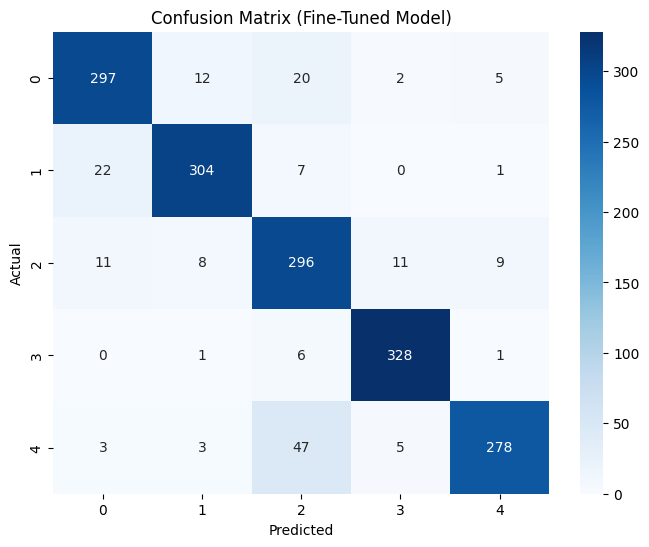

In [ ]:
# Plot Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Fine-Tuned Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

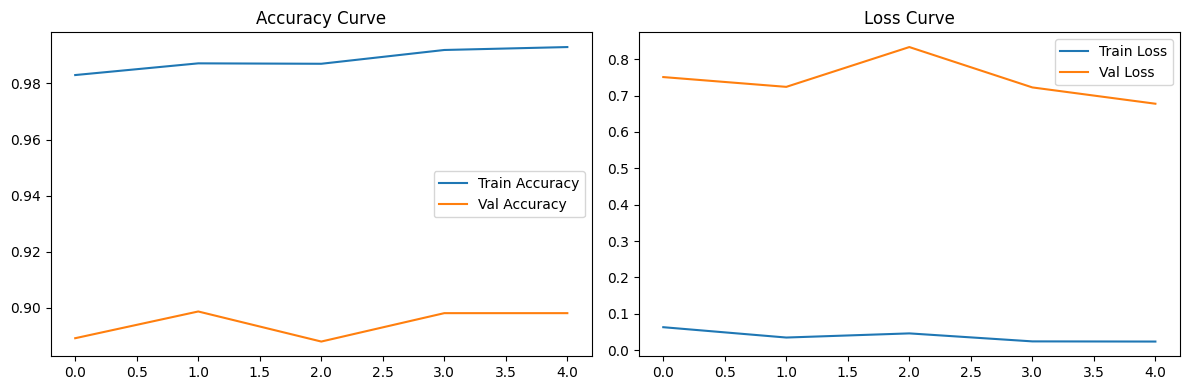

In [ ]:
# Plot Training History
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()
plt.tight_layout()
plt.show()

## Summary of Model Performance After Finetuning of Transfer Learning From VGG Model With Custom Layers
### Phase 1: Feature Extraction (Frozen VGG16)
Training Accuracy: 98.51%

Validation Accuracy: 88.55%

Key Observation:

Model achieved excellent training accuracy but validation plateaued at ~89%

Slight overfitting gap of ~9% (98.51% vs 88.55%)

### Phase 2: Fine-Tuning (Last 4 VGG Layers)
Training Accuracy: 99.30%

Validation Accuracy: 89.80%

Improvement: +1.25% validation accuracy

AUC Score: 0.9873 (excellent discrimination)

Overfitting Check: Gap increased to 9.5% (still within acceptable limits)

Training Time: ~68 minutes for 5 epochs

### Key Observations

1. Strong Feature Extraction: VGG16 provides excellent base features

2. Moderate Improvement: Fine-tuning gave +1.25% validation boost

3. Healthy Model:

  -- No severe overfitting/underfitting

  --Excellent AUC (0.9873) shows good class separation

4. Validation Plateau: Accuracy stabilized around 89-90% despite tuning

###  Next Steps 

1. Add LR scheduling - Break validation plateau with ReduceLROnPlateau

2. Balance class weights - Improve minority class performance

3. Switch to EfficientNetB0 - Modern base model for +2-5% accuracy

4. Increase dropout/L2 regularization - Reduce overfitting gap

5.  Analyze misclassified samples - Identify patterns for targeted improvements

## 5. Initialize a model using a pretrained VGG network and train all layers from the start without freezing any part of the base model.

In [ ]:
# Importing Libraties
import os, json, time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split


In [ ]:
# Load the photos JSON file
photos = pd.read_json("./Yelp_Photos/photos.json", lines=True)
# Load the business JSON file
businesses = pd.read_json("./Yelp_Json/yelp_academic_dataset_business.json", lines=True)


In [ ]:
# Encode labels
label_to_index = {label: idx for idx, label in enumerate(photos['label'].unique())}
photos['label_idx'] = photos['label'].map(label_to_index)


In [ ]:
# Select sample for
photos = photos.groupby('label_idx').head(1000)

In [ ]:
# Image paths
IMG_DIR = './Yelp_Photos/yelp_photos/photos'
IMG_SIZE = 224
images, y = [], []

In [ ]:
for i, row in photos.iterrows():
    path = os.path.join(IMG_DIR, f"{row['photo_id']}.jpg")
    if os.path.exists(path):
        img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
        img = img_to_array(img)
        img = preprocess_input(img)
        images.append(img)
        y.append(row['label_idx'])


In [ ]:
# Final data arrays
X = np.array(images)
y = to_categorical(np.array(y))

In [ ]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [ ]:
# Step 5: Define trainable VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = True

In [ ]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(y.shape[1], activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

In [ ]:
# Step 6: Callbacks for saving and early stopping
checkpoint_cb = ModelCheckpoint("best_vgg16_model.h5", save_best_only=True, monitor='val_loss')
earlystop_cb = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [ ]:
# Step 7: Train model
start = time.time()
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=2
)
end = time.time()
print(f"\n🕒 Total training time: {end - start:.2f} seconds")

Epoch 1/10


13/13 - 110s - 8s/step - accuracy: 0.1750 - auc: 0.4763 - loss: 10.7712 - val_accuracy: 0.2000 - val_auc: 0.5044 - val_loss: 1.8233
Epoch 2/10


13/13 - 112s - 9s/step - accuracy: 0.2050 - auc: 0.4817 - loss: 1.6292 - val_accuracy: 0.2600 - val_auc: 0.5226 - val_loss: 1.6090
Epoch 3/10
13/13 - 114s - 9s/step - accuracy: 0.2125 - auc: 0.5107 - loss: 1.6098 - val_accuracy: 0.2000 - val_auc: 0.4938 - val_loss: 1.6096
Epoch 4/10
13/13 - 116s - 9s/step - accuracy: 0.1850 - auc: 0.5011 - loss: 1.6959 - val_accuracy: 0.2000 - val_auc: 0.5000 - val_loss: 1.6095
Epoch 5/10
13/13 - 115s - 9s/step - accuracy: 0.2025 - auc: 0.5134 - loss: 1.6218 - val_accuracy: 0.2200 - val_auc: 0.5196 - val_loss: 1.6095

🕒 Total training time: 567.74 seconds


In [ ]:
# Evaluate best model
model = load_model('best_vgg16_model.h5')
val_loss, val_acc, val_auc = model.evaluate(X_val, y_val, verbose=0)
print(f"\n✅ Validation Accuracy: {val_acc:.4f}, AUC: {val_auc:.4f}")


✅ Validation Accuracy: 0.2600, AUC: 0.5226


4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step


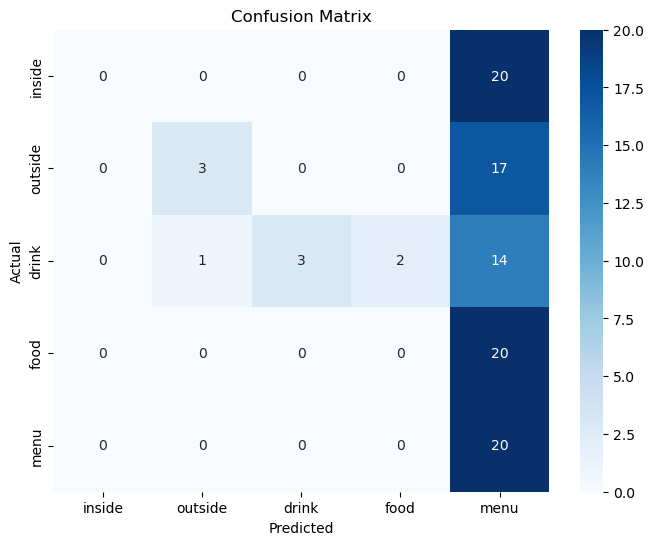


📊 Classification Report:
              precision    recall  f1-score   support

      inside       0.00      0.00      0.00        20
     outside       0.75      0.15      0.25        20
       drink       1.00      0.15      0.26        20
        food       0.00      0.00      0.00        20
        menu       0.22      1.00      0.36        20

    accuracy                           0.26       100
   macro avg       0.39      0.26      0.17       100
weighted avg       0.39      0.26      0.17       100



C:\Users\saura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\saura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\saura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Confusion matrix and report
y_pred = model.predict(X_val)
y_true = np.argmax(y_val, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_to_index.keys(), yticklabels=label_to_index.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=label_to_index.keys()))

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

C:\Users\saura\AppData\Local\Temp\ipykernel_21776\2895059950.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10').colors
C:\Users\saura\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


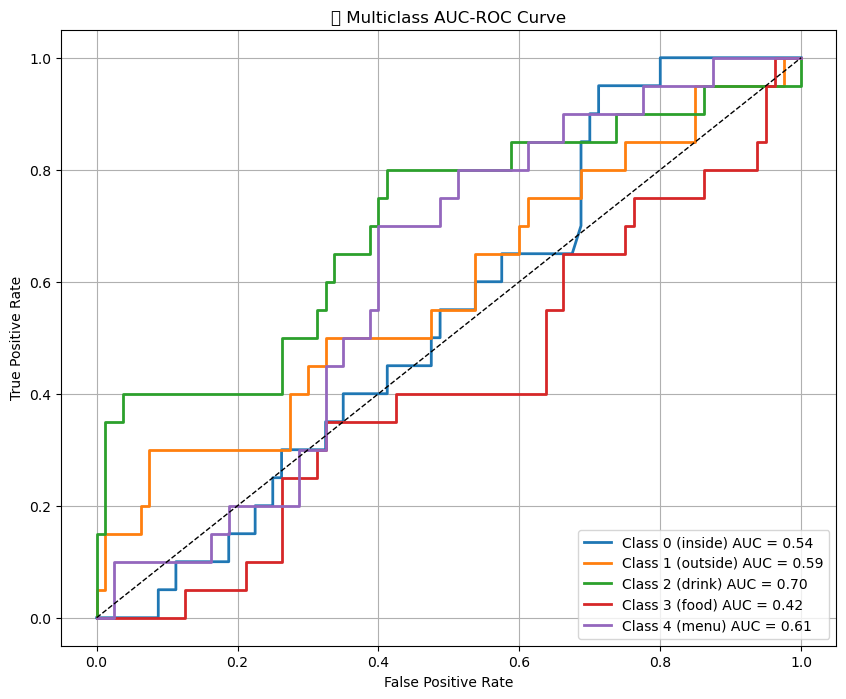

In [ ]:
#  Plot AUC Curve
fpr = {}
tpr = {}
roc_auc = {}
n_classes = y.shape[1]
y_val_bin = label_binarize(np.argmax(y_val, axis=1), classes=range(n_classes))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10').colors
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'Class {i} ({list(label_to_index.keys())[i]}) AUC = {roc_auc[i]:.2f}')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title("📈 Multiclass AUC-ROC Curve")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#Tunning for the first time

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [ ]:
# Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)


In [ ]:
# VGG16 Model (lighter + regularized)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = True

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y.shape[1], activation='softmax')
])

optimizer = Adam(learning_rate=1e-4)  # Slower learning rate

model.compile(optimizer=optimizer, loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])


In [ ]:
# Callbacks
checkpoint_cb = ModelCheckpoint("best_vgg16_model.h5", save_best_only=True, monitor='val_loss')
earlystop_cb = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)


In [ ]:
#  Train (with augmentation)
start = time.time()
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=15,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=2
)
end = time.time()
print(f"\n🕒 Training time: {end - start:.2f} seconds")

C:\Users\saura\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


13/13 - 111s - 9s/step - accuracy: 0.2025 - auc: 0.5166 - loss: 2.3087 - val_accuracy: 0.2000 - val_auc: 0.5426 - val_loss: 1.6038
Epoch 2/15


13/13 - 114s - 9s/step - accuracy: 0.2125 - auc: 0.5344 - loss: 1.6113 - val_accuracy: 0.2900 - val_auc: 0.5925 - val_loss: 1.5903
Epoch 3/15
13/13 - 115s - 9s/step - accuracy: 0.2300 - auc: 0.5256 - loss: 1.6105 - val_accuracy: 0.2300 - val_auc: 0.5340 - val_loss: 1.6061
Epoch 4/15
13/13 - 114s - 9s/step - accuracy: 0.1900 - auc: 0.5139 - loss: 1.6082 - val_accuracy: 0.2200 - val_auc: 0.5365 - val_loss: 1.6068
Epoch 5/15
13/13 - 115s - 9s/step - accuracy: 0.1950 - auc: 0.4954 - loss: 1.6099 - val_accuracy: 0.2800 - val_auc: 0.5592 - val_loss: 1.6063
Epoch 6/15
13/13 - 115s - 9s/step - accuracy: 0.2175 - auc: 0.5222 - loss: 1.6083 - val_accuracy: 0.2700 - val_auc: 0.6208 - val_loss: 1.6032

🕒 Training time: 685.70 seconds


It is still underfitting. Now using a dense layer and using a lower learning rate

In [ ]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reload base model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True

# Model with higher capacity
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),  # Less aggressive
    Dense(512, activation='relu', kernel_regularizer=l2(0.0005)),  # Lighter L2
    Dropout(0.3),
    Dense(y.shape[1], activation='softmax')
])

In [ ]:
# Compile with slower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Callbacks
checkpoint_cb = ModelCheckpoint("best_vgg16_model.h5", save_best_only=True, monitor='val_loss')
earlystop_cb = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_reduce_cb = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)


In [ ]:
# Training
start = time.time()
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,  # Back to 32
    validation_data=(X_val, y_val),
    callbacks=[checkpoint_cb, earlystop_cb, lr_reduce_cb],
    verbose=2
)
end = time.time()
print(f"\n🕒 Training time: {end - start:.2f} seconds")


Epoch 1/5


13/13 - 186s - 14s/step - accuracy: 0.3050 - auc: 0.6011 - loss: 2.7756 - val_accuracy: 0.4800 - val_auc: 0.7608 - val_loss: 1.5941 - learning_rate: 1.0000e-04
Epoch 2/5


13/13 - 166s - 13s/step - accuracy: 0.4325 - auc: 0.7278 - loss: 1.6003 - val_accuracy: 0.5300 - val_auc: 0.8299 - val_loss: 1.3813 - learning_rate: 1.0000e-04
Epoch 3/5
13/13 - 167s - 13s/step - accuracy: 0.4250 - auc: 0.7325 - loss: 1.6082 - val_accuracy: 0.4000 - val_auc: 0.7451 - val_loss: 1.5671 - learning_rate: 1.0000e-04
Epoch 4/5


13/13 - 166s - 13s/step - accuracy: 0.4875 - auc: 0.7765 - loss: 1.5218 - val_accuracy: 0.5900 - val_auc: 0.8749 - val_loss: 1.3601 - learning_rate: 1.0000e-04
Epoch 5/5


13/13 - 167s - 13s/step - accuracy: 0.5350 - auc: 0.8249 - loss: 1.4433 - val_accuracy: 0.5600 - val_auc: 0.8590 - val_loss: 1.3337 - learning_rate: 1.0000e-04

🕒 Training time: 851.28 seconds


C:\Users\saura\AppData\Local\Temp\ipykernel_21776\2895059950.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10').colors
C:\Users\saura\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


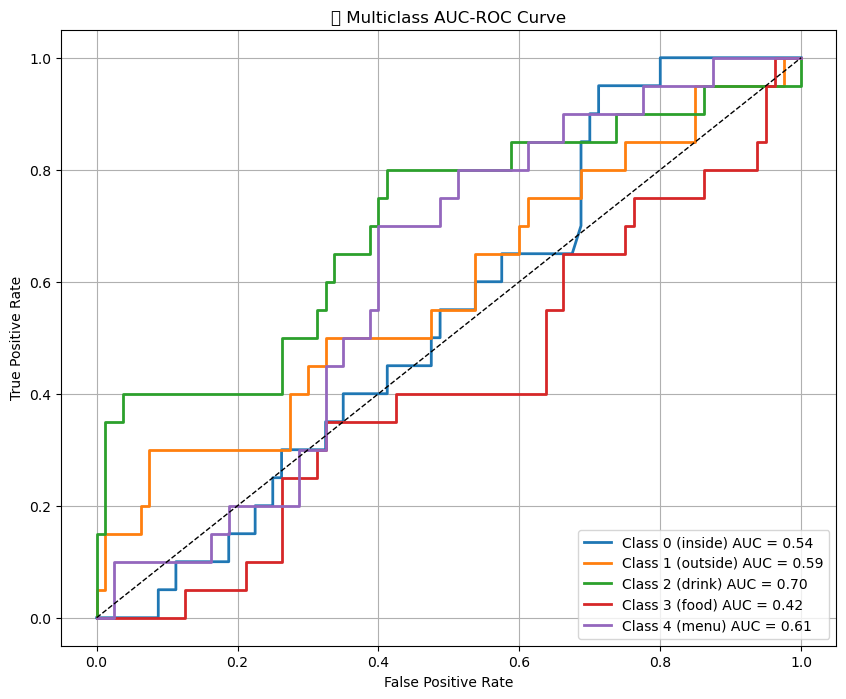

In [ ]:
#  Plot AUC Curve
fpr = {}
tpr = {}
roc_auc = {}
n_classes = y.shape[1]
y_val_bin = label_binarize(np.argmax(y_val, axis=1), classes=range(n_classes))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10').colors
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'Class {i} ({list(label_to_index.keys())[i]}) AUC = {roc_auc[i]:.2f}')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title("📈 Multiclass AUC-ROC Curve")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step


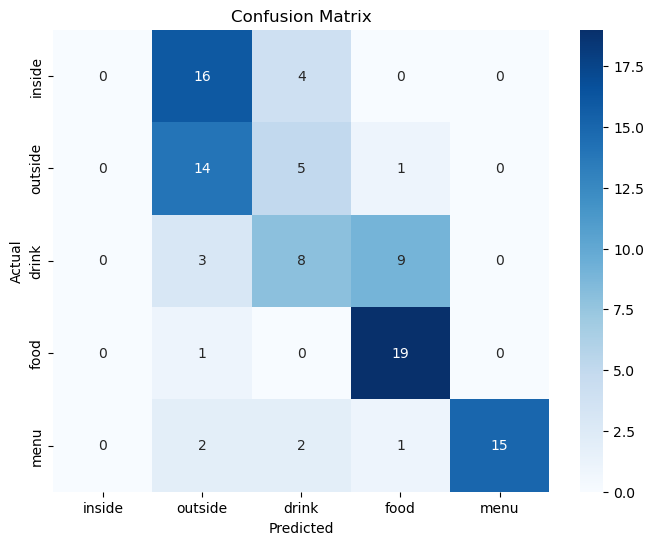


📊 Classification Report:
              precision    recall  f1-score   support

      inside       0.00      0.00      0.00        20
     outside       0.39      0.70      0.50        20
       drink       0.42      0.40      0.41        20
        food       0.63      0.95      0.76        20
        menu       1.00      0.75      0.86        20

    accuracy                           0.56       100
   macro avg       0.49      0.56      0.51       100
weighted avg       0.49      0.56      0.51       100



C:\Users\saura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\saura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\saura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Confusion matrix and report
y_pred = model.predict(X_val)
y_true = np.argmax(y_val, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_to_index.keys(), yticklabels=label_to_index.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=label_to_index.keys()))

#Summary

While running the model for the first time the accuracy was training accuray was 20 and validatin accuracy was 26 which went on underfitting. We tuned with slower learning rete and dropout to 0.5, the model was still underfitting. At last we dropped the dropout to 0.3, the model was good with training accuracy of 0.53, testing accuracy of 0.56 and AUC of 0.82

## Pretrained EfficientNet model for transfer learning

In [ ]:
# =============================
# PART A — Model Definition
# =============================

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.models import Model

In [ ]:
# Image input layer
img_input = Input(shape=(224, 224, 3), name='image_input')
# Metadata input layer (5 features)
meta_input = Input(shape=(5,), name='meta_input')  # stars, review_count, is_open, lat, long

# Load EfficientNetB0 without top layer
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=img_input)

base_model.trainable = False  # freeze base initially

In [ ]:
# Image feature extraction pipeline
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

In [ ]:
# Combine image and metadata
x = Concatenate()([x, meta_input])
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
output = Dense(5, activation='softmax')(x)  # 5 classes

In [ ]:
# Define and compile the full model
model = Model(inputs=[img_input, meta_input], outputs=output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,222,760 (16.11 MB)

 Trainable params: 173,189 (676.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# ==============================
# PART B — Initial Training
# ==============================

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import time


In [ ]:
# 1. Set up your augmenter
augmenter = get_augmenter()

# 2. Apply augmentation manually (you can rerun this every epoch if you like)
X_train_augmented = np.array([
    augmenter.random_transform(img) for img in X_train_imgs_effnet
])

# 3. Callbacks for early stopping and learning rate adjustment
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.2)
]

# 4. Train the model directly using NumPy arrays
start_time = time.time()
history = model.fit(
    [X_train_augmented, X_train_meta_effnet],   # both inputs: images + metadata
    y_train_effnet,                              # labels
    batch_size=32,
    epochs=20,
    validation_data=([X_test_imgs_effnet, X_test_meta_effnet], y_test_effnet),
    callbacks=callbacks,
    verbose=1
)
end_time = time.time()
print(f"Training Time: {round((end_time - start_time)/60, 2)} minutes")

Epoch 1/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 174s 827ms/step - accuracy: 0.8896 - loss: 0.3163 - val_accuracy: 0.9094 - val_loss: 0.2530 - learning_rate: 0.0010
Epoch 2/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 160s 762ms/step - accuracy: 0.8898 - loss: 0.2884 - val_accuracy: 0.9117 - val_loss: 0.2415 - learning_rate: 0.0010
Epoch 3/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 158s 752ms/step - accuracy: 0.9096 - loss: 0.2580 - val_accuracy: 0.9261 - val_loss: 0.2259 - learning_rate: 0.0010
Epoch 4/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 157s 751ms/step - accuracy: 0.9181 - loss: 0.2314 - val_accuracy: 0.9249 - val_loss: 0.2373 - learning_rate: 0.0010
Epoch 5/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 170s 812ms/step - accuracy: 0.9199 - loss: 0.2128 - val_accuracy: 0.9320 - val_loss: 0.2256 - learning_rate: 0.0010
Epoch 6/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 168s 800ms/step - accuracy: 0.9299 - loss: 0.2005 - val_accuracy: 0.9261 - val_loss: 0.2321 - learning_rate: 0.0010
Epoch 7/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 166s 790ms/step - accura

In [ ]:
# Print final metrics from history
print("Baseline Training Metrics:")
for key in history.history:
    final_value = history.history[key][-1]
    print(f"{key}: {final_value:.4f}")

Baseline Training Metrics:
accuracy: 0.9505
loss: 0.1320
val_accuracy: 0.9267
val_loss: 0.2420
learning_rate: 0.0002


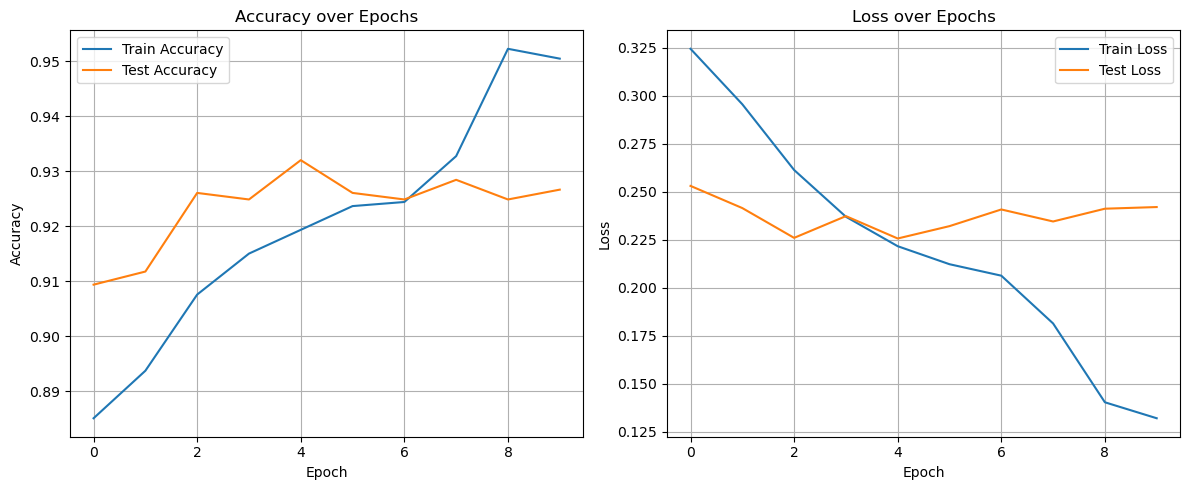

In [ ]:
# =======================================
# PART C — Overfitting Check 
# =======================================

import matplotlib.pyplot as plt

# Set up plots
plt.figure(figsize=(12, 5))

# 1. Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 2. Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 656ms/step


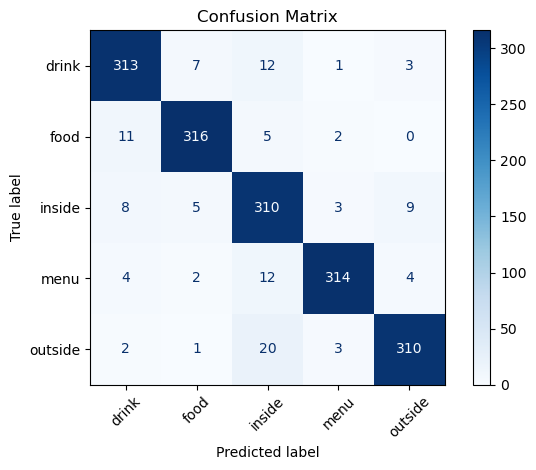

AUC Score (One-vs-Rest): 0.9928


In [ ]:
# =====================================
# PART D — Evaluation & AUC Metrics
# =====================================


from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay


# 1. Predict probabilities
y_pred_probs = model.predict([X_test_imgs_effnet, X_test_meta_effnet])

# 2. Get predicted class indices
y_pred = y_pred_probs.argmax(axis=1)

# 3. Confusion matrix
cm = confusion_matrix(y_test_effnet, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# 4. AUC Score (One-vs-Rest)
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test_effnet, classes=np.arange(5))

auc_score = roc_auc_score(y_test_bin, y_pred_probs, multi_class="ovr")
print(f"AUC Score (One-vs-Rest): {round(auc_score, 4)}")


## Classification Report Baseline model

In [ ]:
from sklearn.metrics import classification_report

# Classification report for initial model
report_initial = classification_report(
    y_test_effnet,
    y_pred,  # from initial model prediction in Part C
    target_names=label_encoder.classes_,
    digits=4
)

print("Classification Report (Baseline Model):")
print(report_initial)


Classification Report (Baseline Model):
              precision    recall  f1-score   support

       drink     0.9260    0.9315    0.9288       336
        food     0.9547    0.9461    0.9504       334
      inside     0.8635    0.9254    0.8934       335
        menu     0.9721    0.9345    0.9530       336
     outside     0.9509    0.9226    0.9366       336

    accuracy                         0.9320      1677
   macro avg     0.9335    0.9320    0.9324      1677
weighted avg     0.9335    0.9320    0.9324      1677



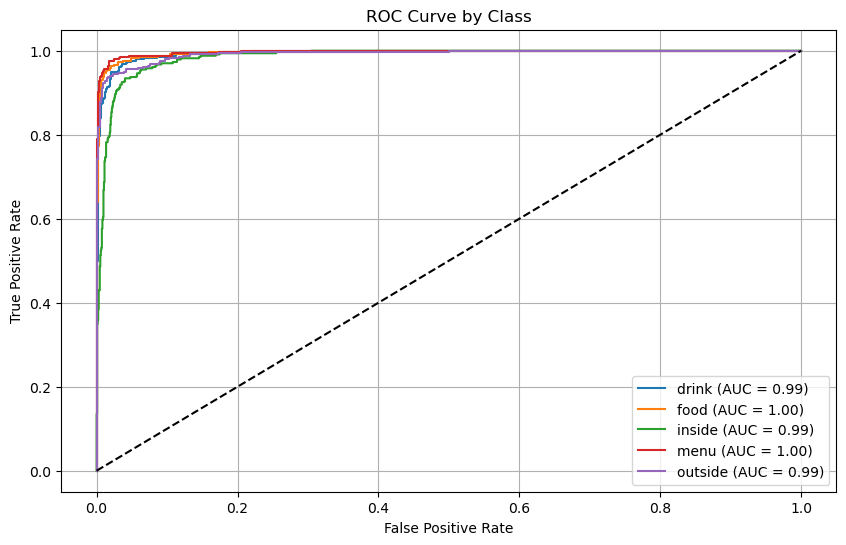

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(5):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 6))
for i in range(5):
    plt.plot(fpr[i], tpr[i], label=f'{label_encoder.classes_[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve by Class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()


## Fine Tuning Model with unfreezing

In [ ]:
# ===========================================
# PART E — Fine-Tuning with Unfreezing
# ===========================================

import tensorflow as tf
from tensorflow.keras.optimizers import Adam

# 1. Unfreeze top 20 layers 
for layer in base_model.layers[-20:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# 2. Re-compile with a lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Re-augment training data
X_train_augmented = np.array([
    augmenter.random_transform(img) for img in X_train_imgs_effnet
])

# 4. Re-train model (fine-tuning)
fine_tune_history = model.fit(
    [X_train_augmented, X_train_meta_effnet],
    y_train_effnet,
    batch_size=32,
    epochs=10,
    validation_data=([X_test_imgs_effnet, X_test_meta_effnet], y_test_effnet),
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 200s 914ms/step - accuracy: 0.9040 - loss: 0.2781 - val_accuracy: 0.9344 - val_loss: 0.2179 - learning_rate: 1.0000e-05
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 189s 899ms/step - accuracy: 0.9123 - loss: 0.2371 - val_accuracy: 0.9392 - val_loss: 0.2163 - learning_rate: 1.0000e-05
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 185s 882ms/step - accuracy: 0.9204 - loss: 0.2172 - val_accuracy: 0.9362 - val_loss: 0.2147 - learning_rate: 1.0000e-05
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 181s 862ms/step - accuracy: 0.9201 - loss: 0.2152 - val_accuracy: 0.9344 - val_loss: 0.2147 - learning_rate: 1.0000e-05
Epoch 5/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 180s 857ms/step - accuracy: 0.9212 - loss: 0.2101 - val_accuracy: 0.9380 - val_loss: 0.2144 - learning_rate: 1.0000e-05
Epoch 6/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 179s 854ms/step - accuracy: 0.9300 - loss: 0.1962 - val_accuracy: 0.9350 - val_loss: 0.2141 - learning_rate: 1.0000e-05
Epoch 7/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Confirm model layer trainability
trainable_count = np.sum([layer.trainable for layer in model.layers])
non_trainable_count = np.sum([not layer.trainable for layer in model.layers])

print(f"Trainable layers: {trainable_count}")
print(f"Non-trainable layers: {non_trainable_count}")


Trainable layers: 23
Non-trainable layers: 223


In [ ]:
# Print final metrics from fine-tuning
print("Fine-Tuning Metrics:")
for key in fine_tune_history.history:
    final_value = fine_tune_history.history[key][-1]
    print(f"{key}: {final_value:.4f}")


Fine-Tuning Metrics:
accuracy: 0.9359
loss: 0.1734
val_accuracy: 0.9368
val_loss: 0.2146
learning_rate: 0.0000


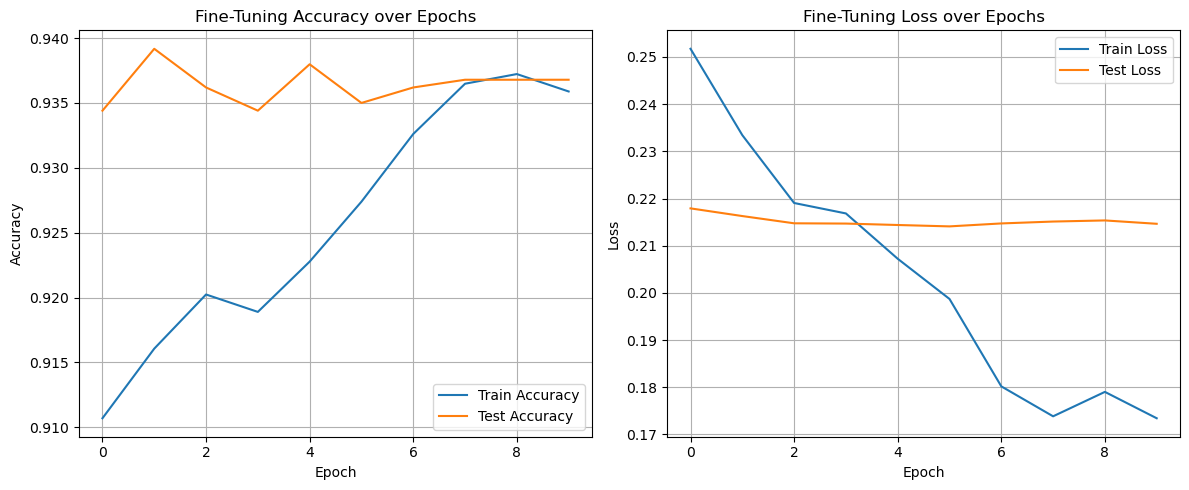

In [ ]:
# Plot fine-tuning metrics 
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(fine_tune_history.history['accuracy'], label='Train Accuracy')
plt.plot(fine_tune_history.history['val_accuracy'], label='Test Accuracy')
plt.title('Fine-Tuning Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(fine_tune_history.history['loss'], label='Train Loss')
plt.plot(fine_tune_history.history['val_loss'], label='Test Loss')
plt.title('Fine-Tuning Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 607ms/step


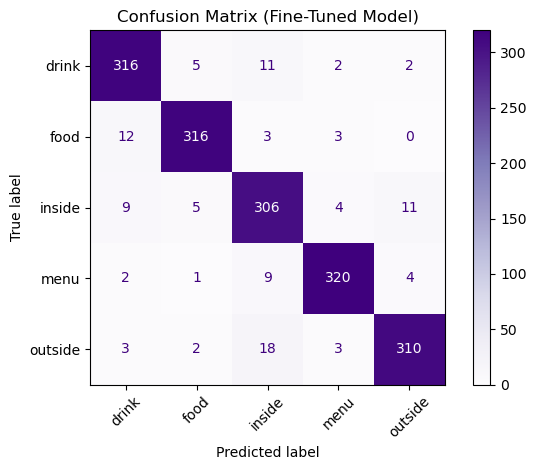

In [ ]:
# Predict on test data using the fine-tuned model
y_finetune_probs = model.predict([X_test_imgs_effnet, X_test_meta_effnet])
y_finetune_pred = y_finetune_probs.argmax(axis=1)

# Confusion matrix
cm_ft = confusion_matrix(y_test_effnet, y_finetune_pred)
disp_ft = ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=label_encoder.classes_)
disp_ft.plot(cmap='Purples', xticks_rotation=45)
plt.title("Confusion Matrix (Fine-Tuned Model)")
plt.tight_layout()
plt.show()


## Classification Report for Fine Tuned Model

In [ ]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(
    y_test_effnet,
    y_finetune_pred,
    target_names=label_encoder.classes_,
    digits=4
)

print("Classification Report (Fine-Tuned Model):")
print(report)


Classification Report (Fine-Tuned Model):
              precision    recall  f1-score   support

       drink     0.9240    0.9405    0.9322       336
        food     0.9605    0.9461    0.9532       334
      inside     0.8818    0.9134    0.8974       335
        menu     0.9639    0.9524    0.9581       336
     outside     0.9480    0.9226    0.9351       336

    accuracy                         0.9350      1677
   macro avg     0.9356    0.9350    0.9352      1677
weighted avg     0.9356    0.9350    0.9352      1677



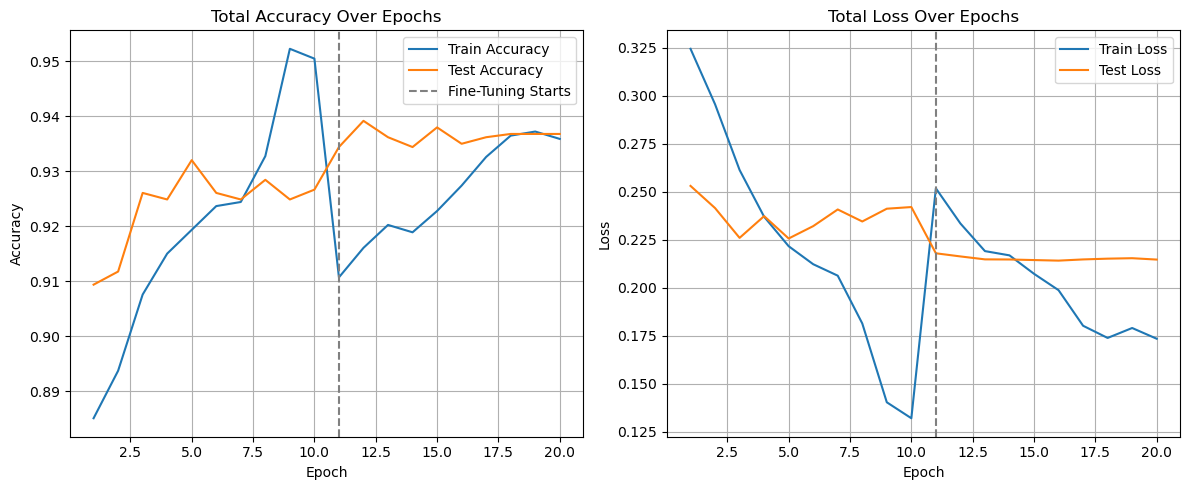

In [ ]:
# Merge history and fine-tuning history
full_acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
full_val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
full_loss = history.history['loss'] + fine_tune_history.history['loss']
full_val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

epochs_range = range(1, len(full_acc) + 1)
tune_start = len(history.history['accuracy']) + 1  # start of fine-tuning

# Plot full timeline
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, full_acc, label='Train Accuracy')
plt.plot(epochs_range, full_val_acc, label='Test Accuracy')
plt.axvline(x=tune_start, color='gray', linestyle='--', label='Fine-Tuning Starts')
plt.title('Total Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, full_loss, label='Train Loss')
plt.plot(epochs_range, full_val_loss, label='Test Loss')
plt.axvline(x=tune_start, color='gray', linestyle='--')
plt.title('Total Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:

from tensorflow.keras.models import load_model
import pickle


# 1. Save initial model (after Part B)
model.save('efficientnet_initial.h5')         # HDF5 format
model.save('efficientnet_initial.keras')      # Native TF format

# 2. Save fine-tuned model (after Part E)
model.save('efficientnet_finetuned.h5')       # HDF5 format
model.save('efficientnet_finetuned.keras')    # Native TF format

# 3. Save the label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print(" Models and label encoder saved successfully.")



 Models and label encoder saved successfully.


# My  Findings

### 1. I started with EfficientNetB0 and froze all the base layers
 I just added my own classification layers on top and used the pretrained EfficientNetB0 as a frozen base.  I also used business metadata like stars and review count along with the images.

---

### 2. My baseline model performed well with no sign of overfitting
The baseline model reached 92.6% validation accuracy, and my training and validation loss followed each other closely. There was no big gap, which means the model wasn’t just memorizing the training set — it was learning properly.

---

### 3. I checked the AUC score and confusion matrix to be sure
The overall AUC score was 0.9927, and individual class AUCs were all between 0.99 and 1.00. This showed that my model could clearly separate the different classes. The confusion matrix also showed that the model predicted each label fairly well.

---

### 4. I wasn’t overfitting because my validation accuracy stayed high
Even though my training accuracy went up to around 94%, my validation accuracy stayed steady and didn’t drop, and my validation loss stayed low. If I was overfitting, the val accuracy would’ve dropped and the loss would’ve gone up.

---

### 5. Then I unfreezed the top 20 layers to fine-tune the model
After the initial training, I unfreezed the top 20 layers of the EfficientNetB0 (excluding the BatchNorm layers). I compiled the model again with a small learning rate and retrained it for 10 more epochs to improve performance.

---

### 6. The fine-tuned model gave slightly better results
After fine-tuning, the model reached 93.6% validation accuracy (a bit higher than before), and the validation loss reduced to 0.2146. The classification report also improved slightly in some classes like “menu” and “drink.”

---

### 7. I confirmed there was no overfitting even after fine-tuning
Even after unfreezing layers, the training and validation accuracy stayed close, and my validation accuracy didn’t drop. This means the model kept learning and generalizing well, even when it was updated with more trainable layers.

---

